# 08 — Bayesian MMM with PyMC-Marketing

## Objective
Re-estimate the Marketing Mix Model using **PyMC-Marketing** (Bayesian MCMC)
and compare results with the Ridge regression from NB06.

### Why Bayesian MMM?

| Aspect | Ridge (NB06) | Bayesian (This Notebook) |
|--------|-------------|-------------------------|
| **Negative coefficients** | Allowed (TV = -$644K) | Prevented via HalfNormal priors |
| **Parameter estimation** | Two-step (NB05 → NB06) | Joint (adstock + saturation + coefficients) |
| **Uncertainty** | Bootstrap CI (1000 resamples) | MCMC posterior distributions |
| **Regularisation** | Ridge penalty (L2) | Bayesian priors (informative) |
| **Saturation** | Mixed (Hill/Log/Power) | Logistic (Hill-equivalent), all channels |

### Data
Same as NB06: 36 monthly observations (FY2023–FY2025), 7 media channels, 7 control features.

---
## Section 0 — Setup & Data Loading

In [1]:
# ---------- imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json
from pathlib import Path

import pymc as pm
import arviz as az
from pymc_marketing.mmm import (
    MMM,
    GeometricAdstock,
    LogisticSaturation,
)
import pymc_marketing

warnings.filterwarnings('ignore')

# ---------- version check ----------
print(f'PyMC version         : {pm.__version__}')
print(f'ArviZ version        : {az.__version__}')
print(f'PyMC-Marketing       : {pymc_marketing.__version__}')

pmm_version = tuple(int(x) for x in pymc_marketing.__version__.split('.')[:2])
assert pmm_version >= (0, 10), f'Requires pymc-marketing >= 0.10.0, got {pymc_marketing.__version__}'

# ---------- plot settings ----------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 10,
                      'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_palette('husl')

# ---------- paths ----------
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path   = project_root / 'reports' / 'figures'
figures_path.mkdir(parents=True, exist_ok=True)

print(f'Project root         : {project_root}')

PyMC version         : 5.27.1
ArviZ version        : 0.23.4
PyMC-Marketing       : 0.18.0
Project root         : /Users/tuta/Desktop/busa693-clubpiscine


In [2]:
# ---------- load data ----------
# Use CSV (pkl has Python version compatibility issues)
df_raw = pd.read_csv(processed_path / 'sales_spend_weather.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'Shape : {df_raw.shape}')
print(f'Date range : {df_raw["date"].min().date()} -- {df_raw["date"].max().date()}')
print(f'Fiscal years: {sorted(df_raw["year"].unique())}')
print(f'Total revenue (3yr): ${df_raw["total_all_revenue"].sum():,.0f}')

SPEND_COLS = [c for c in df_raw.columns if c.startswith('spend_') and c != 'spend_total']
print(f'Total media spend  : ${df_raw[SPEND_COLS].sum().sum():,.0f}')

Shape : (36, 43)
Date range : 2022-11-01 -- 2025-10-01
Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]
Total revenue (3yr): $512,411,602
Total media spend  : $10,257,505


---
## Section 1 — Data Preparation for PyMC-Marketing

PyMC-Marketing applies **adstock and saturation internally** — we pass raw spend, not transformed values.

Required format:
- `date_column`: a date column
- `channel_columns`: raw media spend (no adstock/saturation)
- `control_columns`: exogenous controls (Fourier seasonality + weather)
- `y`: target revenue

In [3]:
# ---------- prepare model dataframe ----------
df = df_raw.copy()

# Channel columns: use raw spend (PyMC-Marketing applies its own adstock + saturation)
CHANNEL_COLS = [
    'spend_television',
    'spend_radio',
    'spend_panneaux',
    'spend_social_media',
    'spend_preroll',
    'spend_banniere_web',
    'spend_circulaire_digitale',
]

# Fill NaN spend with 0
for col in CHANNEL_COLS:
    df[col] = df[col].fillna(0)

# Weather controls only — scale to z-scores
# (Fourier seasonality handled by yearly_seasonality=2 in the model, NOT as controls)
for wcol in ['total_sunshine_hours', 'total_precipitation', 'days_above_25']:
    df[f'{wcol}_scaled'] = (df[wcol] - df[wcol].mean()) / df[wcol].std()

CONTROL_COLS = [
    'total_sunshine_hours_scaled',
    'total_precipitation_scaled',
    'days_above_25_scaled',
]

TARGET = 'total_all_revenue'

# Ensure date column is proper datetime
df['date'] = pd.to_datetime(df['date'])

print(f'Channels ({len(CHANNEL_COLS)}): {CHANNEL_COLS}')
print(f'Controls ({len(CONTROL_COLS)}): {CONTROL_COLS}')
print(f'  NOTE: Fourier seasonality removed from controls — using built-in yearly_seasonality=2')
print(f'  This gives Fourier terms their own gamma_fourier prior (Laplace) instead of gamma_control (Normal)')
print(f'Target: {TARGET}')
print(f'Observations: {len(df)}')
print()

# Show channel spend summary
for col in CHANNEL_COLS:
    total = df[col].sum()
    nz = (df[col] > 0).sum()
    print(f'  {col:35s}  ${total:>12,.0f}  non-zero: {nz}/{len(df)}')

Channels (7): ['spend_television', 'spend_radio', 'spend_panneaux', 'spend_social_media', 'spend_preroll', 'spend_banniere_web', 'spend_circulaire_digitale']
Controls (3): ['total_sunshine_hours_scaled', 'total_precipitation_scaled', 'days_above_25_scaled']
  NOTE: Fourier seasonality removed from controls — using built-in yearly_seasonality=2
  This gives Fourier terms their own gamma_fourier prior (Laplace) instead of gamma_control (Normal)
Target: total_all_revenue
Observations: 36

  spend_television                     $   3,948,951  non-zero: 20/36
  spend_radio                          $   2,167,277  non-zero: 23/36
  spend_panneaux                       $     292,495  non-zero: 9/36
  spend_social_media                   $     827,421  non-zero: 36/36
  spend_preroll                        $     812,648  non-zero: 27/36
  spend_banniere_web                   $   1,762,168  non-zero: 36/36
  spend_circulaire_digitale            $     446,546  non-zero: 20/36


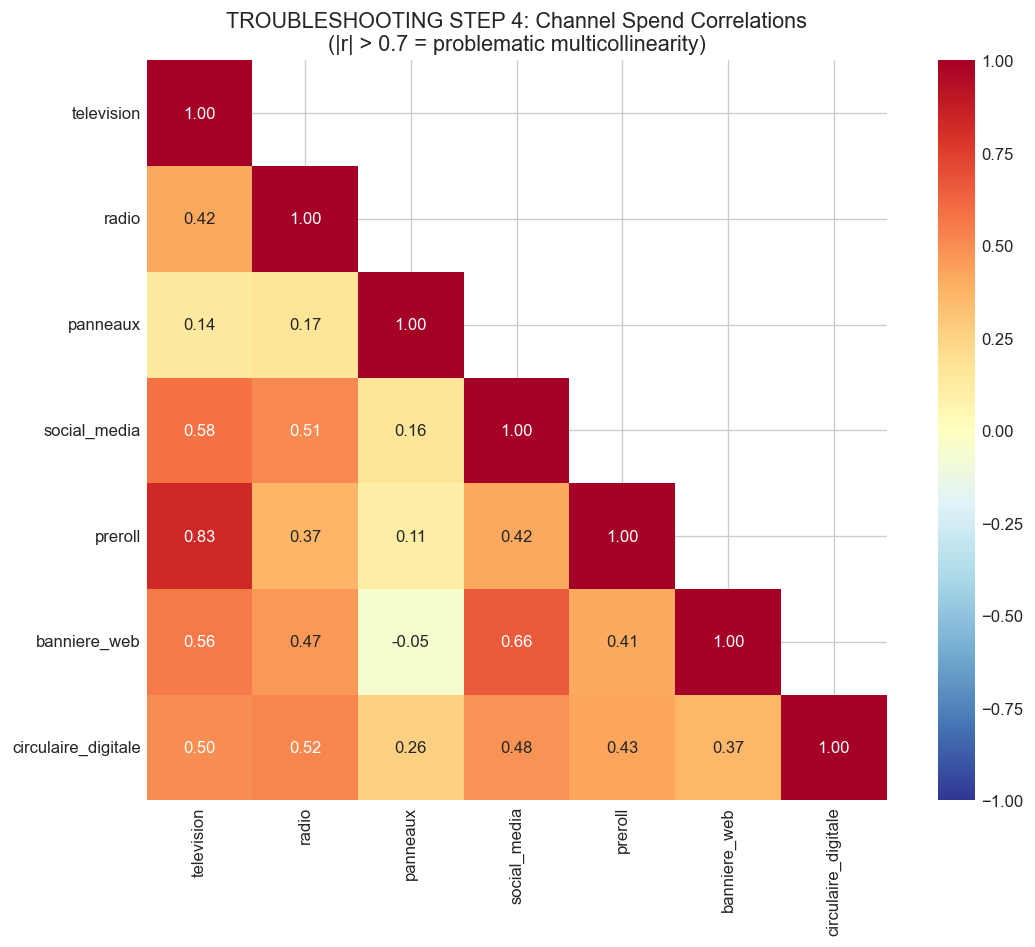

Channel Correlation Check:
  NOTE:    television <-> social_media: r=0.58 (moderate)
  NOTE:    television <-> banniere_web: r=0.56 (moderate)
  NOTE:    radio <-> social_media: r=0.51 (moderate)
  NOTE:    radio <-> circulaire_digitale: r=0.52 (moderate)
  NOTE:    social_media <-> banniere_web: r=0.66 (moderate)

  1 pair(s) with |r| > 0.7.
  Consider combining these channels to improve identifiability.


In [4]:
# ---------- TROUBLESHOOTING STEP 4: Channel Spend Correlations ----------
# Highly correlated channels (>0.7) cannot be distinguished by the model.
# This is a data-level check — run BEFORE fitting.

corr_matrix = df[CHANNEL_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
labels = [c.replace("spend_", "") for c in CHANNEL_COLS]
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, vmin=-1, vmax=1, xticklabels=labels, yticklabels=labels,
            ax=ax, square=True)
ax.set_title("TROUBLESHOOTING STEP 4: Channel Spend Correlations\n"
             "(|r| > 0.7 = problematic multicollinearity)", fontsize=13)
plt.tight_layout()
plt.savefig(figures_path / "bayesian_channel_correlations.png", dpi=150)
plt.show()

# Flag problematic pairs
print("Channel Correlation Check:")
print("=" * 60)
high_corr_pairs = []
for i in range(len(CHANNEL_COLS)):
    for j in range(i+1, len(CHANNEL_COLS)):
        r = corr_matrix.iloc[i, j]
        ch1 = CHANNEL_COLS[i].replace("spend_", "")
        ch2 = CHANNEL_COLS[j].replace("spend_", "")
        if abs(r) > 0.7:
            high_corr_pairs.append((ch1, ch2, r))
            print(f"  WARNING: {ch1} <-> {ch2}: r={r:.2f} (HIGH — consider combining)")
        elif abs(r) > 0.5:
            print(f"  NOTE:    {ch1} <-> {ch2}: r={r:.2f} (moderate)")

if not high_corr_pairs:
    print("  No pairs with |r| > 0.7 — multicollinearity is manageable.")
else:
    print(f"\n  {len(high_corr_pairs)} pair(s) with |r| > 0.7.")
    print("  Consider combining these channels to improve identifiability.")


---
## Section 2 — Model Specification with Proper Priors

### Three Key Fixes (from PyMC-Marketing docs & GitHub issues)

**Problem**: Controls contributed 0% in waterfall — all seasonal variance routed through media (83% attribution).

| Fix | What | Why |
|-----|------|-----|
| **1. Built-in `yearly_seasonality=2`** | Fourier terms get `gamma_fourier` (Laplace) prior | Manual Fourier as controls got `gamma_control` (Normal σ=2), too flat |
| **2. Spend-share `saturation_beta`** | σ = n_channels × spend_share × scale | Channels with less spend get tighter priors (prevents over-attribution) |
| **3. Intercept `Normal(0.5, 0.2)`** | Push base revenue to 50-70% | Default `Normal(0, 2)` allows unrealistic near-zero base |

Sources: [PyMC-Marketing Quickstart](https://www.pymc-marketing.io/en/0.17.1/notebooks/mmm/mmm_quickstart.html), [Issue #1804](https://github.com/pymc-labs/pymc-marketing/issues/1804), [Issue #1469](https://github.com/pymc-labs/pymc-marketing/issues/1469)

In [5]:
# ---------- model specification with proper priors ----------
from pymc_extras.prior import Prior

# Load NB05 calibrated decay rates
with open(processed_path / 'optimal_transformation_params.json') as f:
    nb05_params = json.load(f)

# === ADSTOCK PRIORS (same as before: Beta centered on NB05 decay rates) ===
k = 20  # concentration parameter
nb05_decays = [
    nb05_params['decay_rates']['media_television'],           # 0.1
    nb05_params['decay_rates']['media_radio'],                # 0.5
    nb05_params['decay_rates']['media_panneaux'],             # 0.4
    nb05_params['decay_rates']['media_social_media'],         # 0.4
    nb05_params['decay_rates']['media_preroll'],              # 0.1
    nb05_params['decay_rates']['media_banniere_web'],         # 0.3
    nb05_params['decay_rates']['media_circulaire_digitale'],  # 0.3
]
nb05_decays_clipped = np.clip(nb05_decays, 0.05, 0.95)
adstock_alpha_a = nb05_decays_clipped * k
adstock_alpha_b = (1 - nb05_decays_clipped) * k

# === FIX 2: SPEND-SHARE-BASED saturation_beta PRIORS ===
# From PyMC-Marketing quickstart: sigma = HALFNORMAL_SCALE * n_channels * spend_share
# This ensures channels with small spend get tight priors
total_spend_per_channel = df[CHANNEL_COLS].sum()
spend_share = total_spend_per_channel / total_spend_per_channel.sum()
n_channels = len(CHANNEL_COLS)
HALFNORMAL_SCALE = 1 / np.sqrt(1 - 2 / np.pi)
spend_share_sigma = HALFNORMAL_SCALE * n_channels * spend_share.to_numpy()

print('FIX 2 — Spend-Share-Based saturation_beta Priors:')
print('=' * 75)
print(f'{"Channel":30s}  {"Spend Share":>12s}  {"New Sigma":>10s}  {"Old Sigma":>10s}')
print('-' * 75)
old_sigmas = [0.05, 0.15, 0.15, 0.25, 0.50, 0.15, 0.05]  # previous ad-hoc values
for i, ch in enumerate(CHANNEL_COLS):
    print(f'  {ch.replace("spend_", ""):28s}  '
          f'{spend_share.iloc[i]:>12.3f}  '
          f'{spend_share_sigma[i]:>10.3f}  '
          f'{old_sigmas[i]:>10.2f}')

# === BUILD MODEL CONFIG with Prior objects ===
model_config = {
    # FIX 3: Intercept centered at 0.5 (base = ~50% of scaled revenue)
    'intercept': Prior('Normal', mu=0.5, sigma=0.2),
    
    # FIX 2: Spend-share-based media priors
    'saturation_beta': Prior('HalfNormal', sigma=spend_share_sigma, dims='channel'),
    
    # Adstock: informative from NB05 (unchanged)
    'adstock_alpha': Prior('Beta', alpha=adstock_alpha_a, beta=adstock_alpha_b, dims='channel'),
    
    # Saturation lambda: keep default
    'saturation_lam': Prior('Gamma', alpha=3, beta=1, dims='channel'),
    
    # Controls: default Normal(0, 2) — wide enough for weather
    'gamma_control': Prior('Normal', mu=0, sigma=2, dims='control'),
    
    # FIX 1: Fourier gets its own Laplace prior (via yearly_seasonality=2)
    'gamma_fourier': Prior('Laplace', mu=0, b=1, dims='fourier_mode'),
    
    # Likelihood
    'likelihood': Prior('Normal', sigma=Prior('HalfNormal', sigma=2)),
}

sampler_config = {
    'draws': 2000,
    'tune': 2000,
    'chains': 4,
    'target_accept': 0.95,
}

# ---------- model specification ----------
mmm = MMM(
    date_column='date',
    channel_columns=CHANNEL_COLS,
    control_columns=CONTROL_COLS,        # Weather only (3 controls)
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,                # FIX 1: Built-in Fourier with gamma_fourier prior
    model_config=model_config,
    sampler_config=sampler_config,
)

print(f'\nModel created with THREE FIXES applied:')
print(f'  FIX 1: yearly_seasonality=2 (Fourier gets dedicated Laplace prior)')
print(f'  FIX 2: Spend-share-based saturation_beta sigmas')
print(f'  FIX 3: Intercept = Normal(0.5, 0.2) (base ~50-70% of revenue)')
print(f'  Channels: {len(CHANNEL_COLS)}')
print(f'  Controls: {len(CONTROL_COLS)} (weather only)')
print(f'  Sampling: {sampler_config}')
print()
print('Full model_config:')
for key, val in mmm.model_config.items():
    print(f'  {key}: {val}')

FIX 2 — Spend-Share-Based saturation_beta Priors:
Channel                          Spend Share   New Sigma   Old Sigma
---------------------------------------------------------------------------
  television                           0.385       4.471        0.05
  radio                                0.211       2.454        0.15
  panneaux                             0.029       0.331        0.15
  social_media                         0.081       0.937        0.25
  preroll                              0.079       0.920        0.50
  banniere_web                         0.172       1.995        0.15
  circulaire_digitale                  0.044       0.506        0.05

Model created with THREE FIXES applied:
  FIX 1: yearly_seasonality=2 (Fourier gets dedicated Laplace prior)
  FIX 2: Spend-share-based saturation_beta sigmas
  FIX 3: Intercept = Normal(0.5, 0.2) (base ~50-70% of revenue)
  Channels: 7
  Controls: 3 (weather only)
  Sampling: {'draws': 2000, 'tune': 2000, 'chains': 4, 

X columns (11): ['spend_television', 'spend_radio', 'spend_panneaux', 'spend_social_media', 'spend_preroll', 'spend_banniere_web', 'spend_circulaire_digitale', 'total_sunshine_hours_scaled', 'total_precipitation_scaled', 'days_above_25_scaled', 'date']
Note: No Fourier columns — yearly_seasonality=2 generates them internally



Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept, saturation_beta, saturation_lam, y, y_sigma]


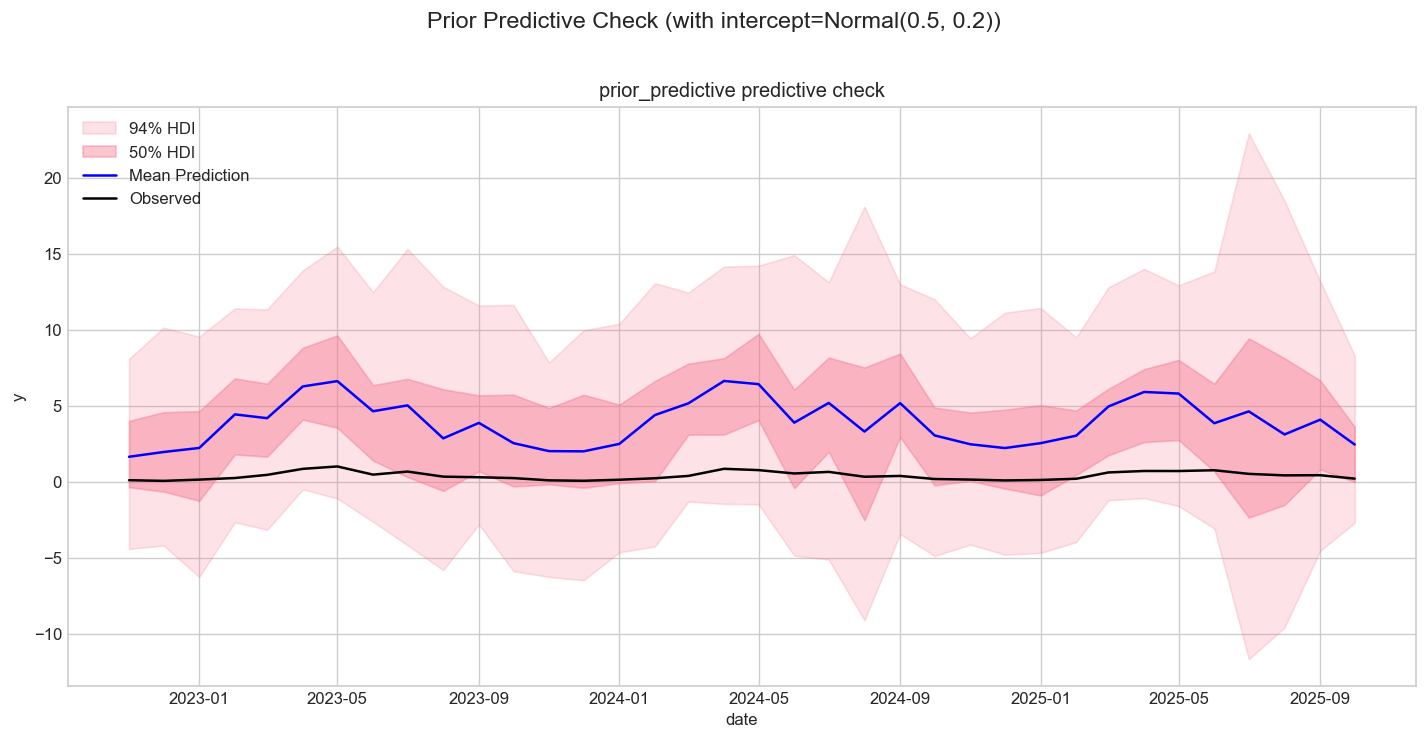

Prior predictive check complete.
With intercept centered at 0.5, the prior predictive should be centered near actual revenue.


In [6]:
# ---------- prior predictive check ----------
X = df[CHANNEL_COLS + CONTROL_COLS + ['date']].copy()
y = df[TARGET].values

print(f'X columns ({len(X.columns)}): {list(X.columns)}')
print(f'Note: No Fourier columns — yearly_seasonality=2 generates them internally')
print()

# Sample from priors to check they are reasonable
mmm.sample_prior_predictive(X, y, samples=500, random_seed=42)

fig = mmm.plot_prior_predictive()
fig.suptitle('Prior Predictive Check (with intercept=Normal(0.5, 0.2))', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_prior_predictive.png', dpi=150)
plt.show()

print('Prior predictive check complete.')
print('With intercept centered at 0.5, the prior predictive should be centered near actual revenue.')

---
## Section 3 — MCMC Fitting

NUTS (No-U-Turn Sampler) with informative priors:
- **4 chains** for convergence diagnostics (R-hat)
- **2000 tuning + 2000 draws** per chain (more than default for small n=36)
- **target_accept=0.95** for better exploration with correlated parameters

Sampling parameters are set via `sampler_config` at model construction.

In [7]:
%%time
# ---------- fit the model ----------
# sampler_config was set during construction: draws=2000, tune=2000, target_accept=0.95
mmm.fit(
    X=X,
    y=y,
    random_seed=42,
)

# ---------- divergence check ----------
divergences = int(mmm.idata.sample_stats.diverging.sum().values)
print(f'\nModel fitting complete.')
print(f'Divergent transitions: {divergences}')
if divergences > 0:
    print('WARNING: Divergences detected. Consider:')
    print('  - Increasing target_accept (currently 0.95, try 0.99)')
    print('  - Using tighter informative priors')
    print('  - Reducing model complexity')
else:
    print('No divergences — sampler explored posterior cleanly.')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 122 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


Output()


Model fitting complete.
Divergent transitions: 1
  - Increasing target_accept (currently 0.95, try 0.99)
  - Using tighter informative priors
  - Reducing model complexity
CPU times: user 13.5 s, sys: 2.32 s, total: 15.8 s
Wall time: 2min 15s


---
## Section 4 — Posterior Diagnostics

Check for MCMC convergence:
- **R-hat < 1.05** for all parameters (chains are mixing)
- **ESS > 400** for reliable posterior summaries
- Trace plots should look like "hairy caterpillars" (well-mixed)

In [8]:
# ---------- convergence summary ----------

# First, list all posterior variable names for reference
print('Posterior variables available:')
for var in sorted(mmm.fit_result.data_vars):
    dims = mmm.fit_result[var].dims
    print(f'  {var:50s}  dims={dims}')
print()

# Include gamma_fourier now that we use yearly_seasonality=2
summary = az.summary(
    mmm.idata,
    var_names=['intercept', 'saturation_beta', 'gamma_control', 'gamma_fourier',
               'adstock_alpha', 'saturation_lam', 'y_sigma'],
    round_to=3,
)
print('Posterior Summary (key parameters):')
print('=' * 90)
print(summary.to_string())
print()

# Check convergence
rhat_ok = (summary['r_hat'] < 1.05).all()
ess_ok = (summary['ess_bulk'] > 400).all()
print(f'R-hat < 1.05 for all params: {"YES" if rhat_ok else "NO — CHECK DIAGNOSTICS"}')
print(f'ESS > 400 for all params:    {"YES" if ess_ok else "NO — INCREASE DRAWS"}')

Posterior variables available:
  adstock_alpha                                       dims=('chain', 'draw', 'channel')
  channel_contribution                                dims=('chain', 'draw', 'date', 'channel')
  channel_contribution_original_scale                 dims=('chain', 'draw', 'date', 'channel')
  control_contribution                                dims=('chain', 'draw', 'date', 'control')
  control_contribution_original_scale                 dims=('chain', 'draw', 'date', 'control')
  fourier_contribution                                dims=('chain', 'draw', 'date', 'fourier_mode')
  gamma_control                                       dims=('chain', 'draw', 'control')
  gamma_fourier                                       dims=('chain', 'draw', 'fourier_mode')
  intercept                                           dims=('chain', 'draw')
  mu                                                  dims=('chain', 'draw', 'date')
  saturation_beta                                    

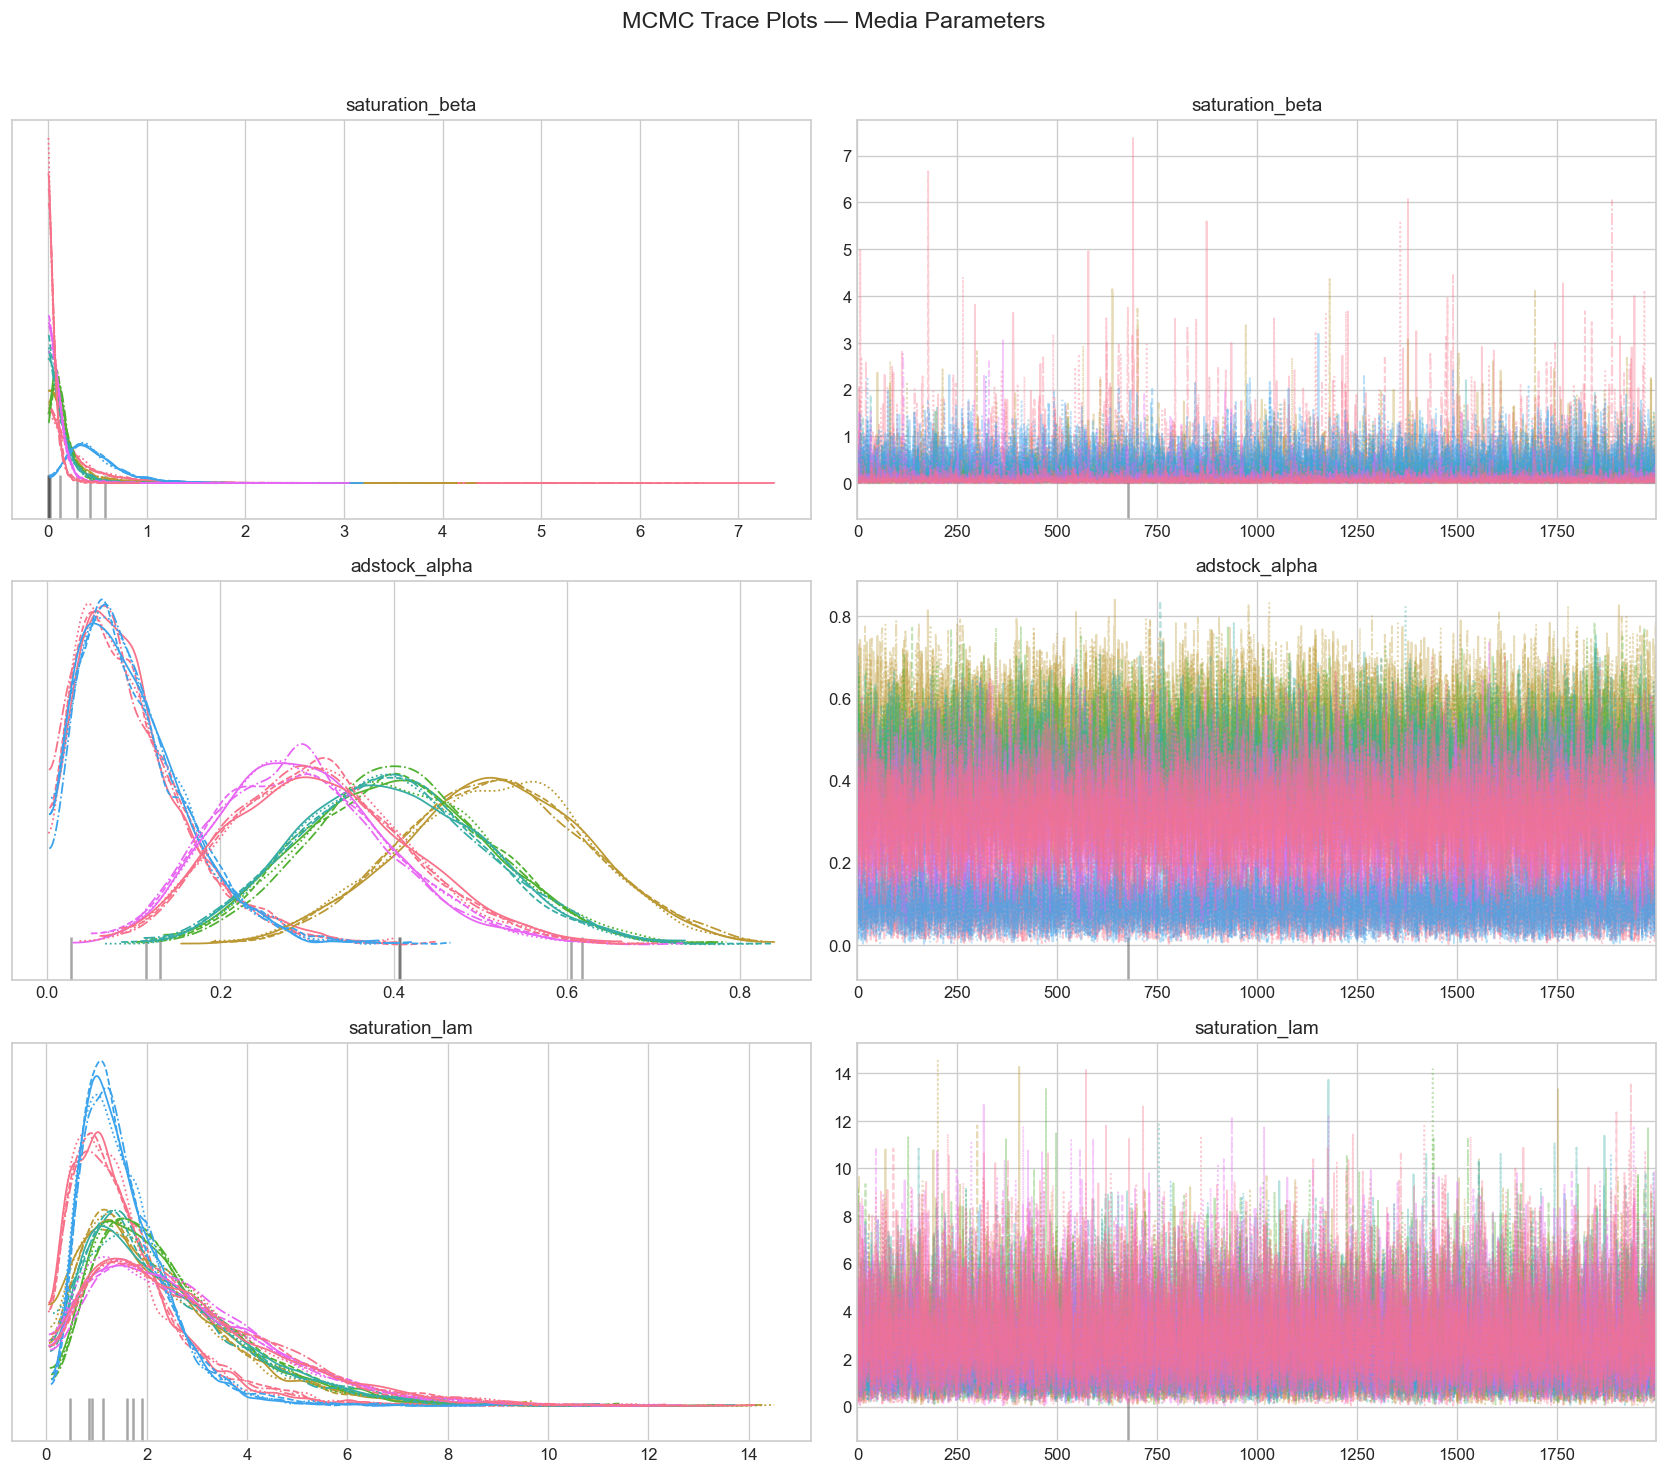

In [9]:
# ---------- trace plots for media parameters ----------
axes = az.plot_trace(
    mmm.idata,
    var_names=['saturation_beta', 'adstock_alpha', 'saturation_lam'],
    compact=True,
    figsize=(14, 12),
)
plt.suptitle('MCMC Trace Plots — Media Parameters', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_trace_plots.png', dpi=150)
plt.show()

Sampling: [y]


Output()

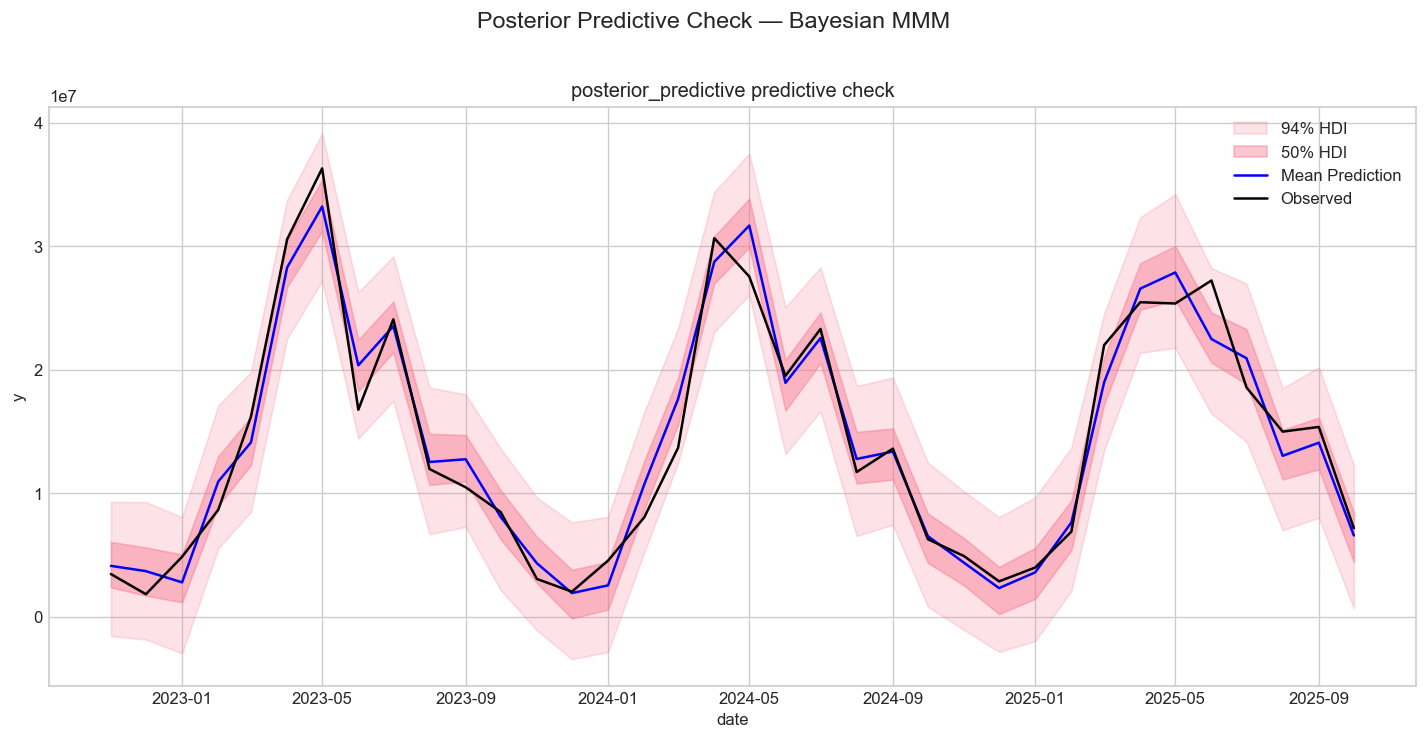

In [10]:
# ---------- posterior predictive check ----------
mmm.sample_posterior_predictive(X, random_seed=42)

fig = mmm.plot_posterior_predictive(original_scale=True)
fig.suptitle('Posterior Predictive Check — Bayesian MMM', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_posterior_predictive.png', dpi=150)
plt.show()

In [11]:
# ---------- model fit assessment ----------
y_pred_posterior = mmm.predict_posterior(X, combined=False)
y_pred_mean = y_pred_posterior.mean(dim=['chain', 'draw']).values

from sklearn.metrics import r2_score, mean_absolute_error

r2_bayes = r2_score(y, y_pred_mean)
mae_bayes = mean_absolute_error(y, y_pred_mean)

print(f'Bayesian MMM — Model Fit:')
print(f'  R-squared (posterior mean, in-sample): {r2_bayes:.3f}')
print(f'  MAE: ${mae_bayes:,.0f}')
print()

# ---------- PSIS-LOO Cross-Validation ----------
# Compute log likelihood (not stored by default in pymc-marketing)
print('Computing log likelihood for LOO-CV...')
with mmm.model:
    pm.compute_log_likelihood(mmm.idata)

print('PSIS-LOO Cross-Validation (Bayesian equivalent of LOOCV):')
print('-' * 60)
loo_result = az.loo(mmm.idata, pointwise=True)
print(f'  elpd_loo = {loo_result.elpd_loo:.1f}  (se = {loo_result.se:.1f})')
print(f'  p_loo (effective parameters) = {loo_result.p_loo:.1f}')
k_values = loo_result.pareto_k
n_bad = int((k_values > 0.7).sum())
print(f'  Pareto k > 0.7 (problematic obs): {n_bad}/{len(k_values)}')
if n_bad > 0:
    print(f'  WARNING: {n_bad} observations have high Pareto k — LOO estimates unreliable for those points.')
    print(f'  Consider using k-fold CV or removing influential outliers.')
else:
    print(f'  All Pareto k < 0.7 — LOO estimates reliable.')

print()
print('Comparison with Ridge (NB06):')
print(f'  Ridge in-sample R²:   0.966')
print(f'  Ridge LOOCV R²:       0.912')
print(f'  Ridge MAE:            $1,368,274')
print()
print(f'  Bayesian in-sample R²: {r2_bayes:.3f}')
print(f'  Bayesian elpd_loo:     {loo_result.elpd_loo:.1f} (not directly comparable to R²)')
print(f'  Bayesian MAE:          ${mae_bayes:,.0f}')

Sampling: [y]


Output()

Bayesian MMM — Model Fit:
  R-squared (posterior mean, in-sample): 0.953
  MAE: $1,673,937

Computing log likelihood for LOO-CV...


Output()

PSIS-LOO Cross-Validation (Bayesian equivalent of LOOCV):
------------------------------------------------------------
  elpd_loo = -1929.4  (se = 363.6)
  p_loo (effective parameters) = 1660.9
  Pareto k > 0.7 (problematic obs): 27/36
  Consider using k-fold CV or removing influential outliers.

Comparison with Ridge (NB06):
  Ridge in-sample R²:   0.966
  Ridge LOOCV R²:       0.912
  Ridge MAE:            $1,368,274

  Bayesian in-sample R²: 0.953
  Bayesian elpd_loo:     -1929.4 (not directly comparable to R²)
  Bayesian MAE:          $1,673,937


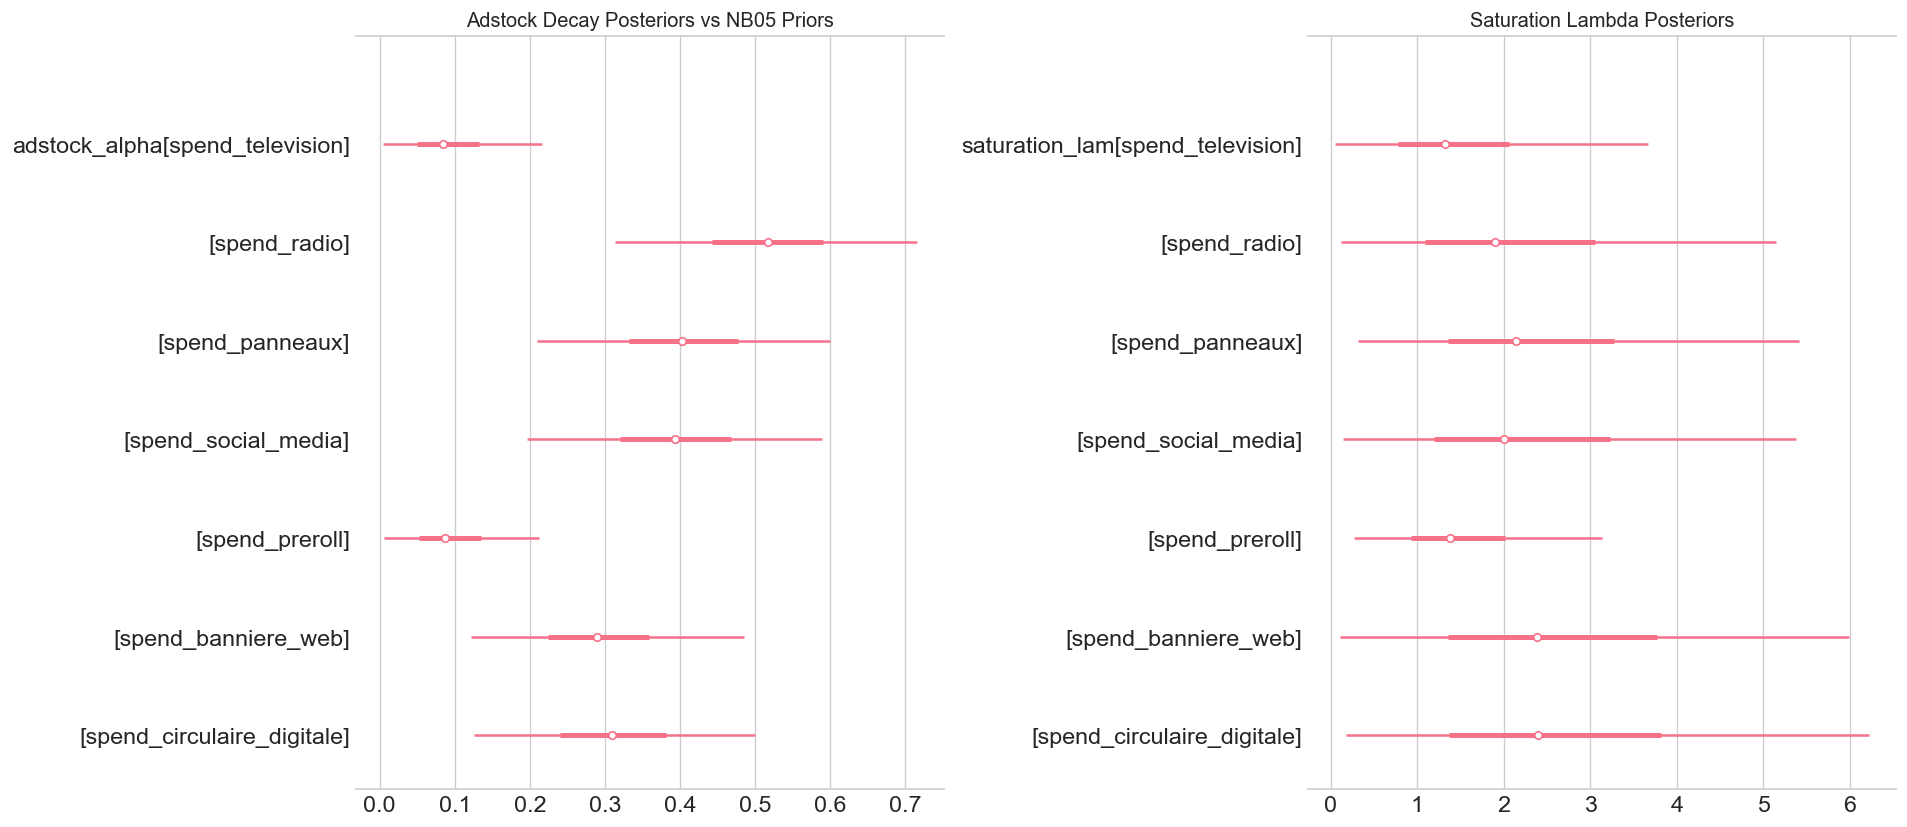

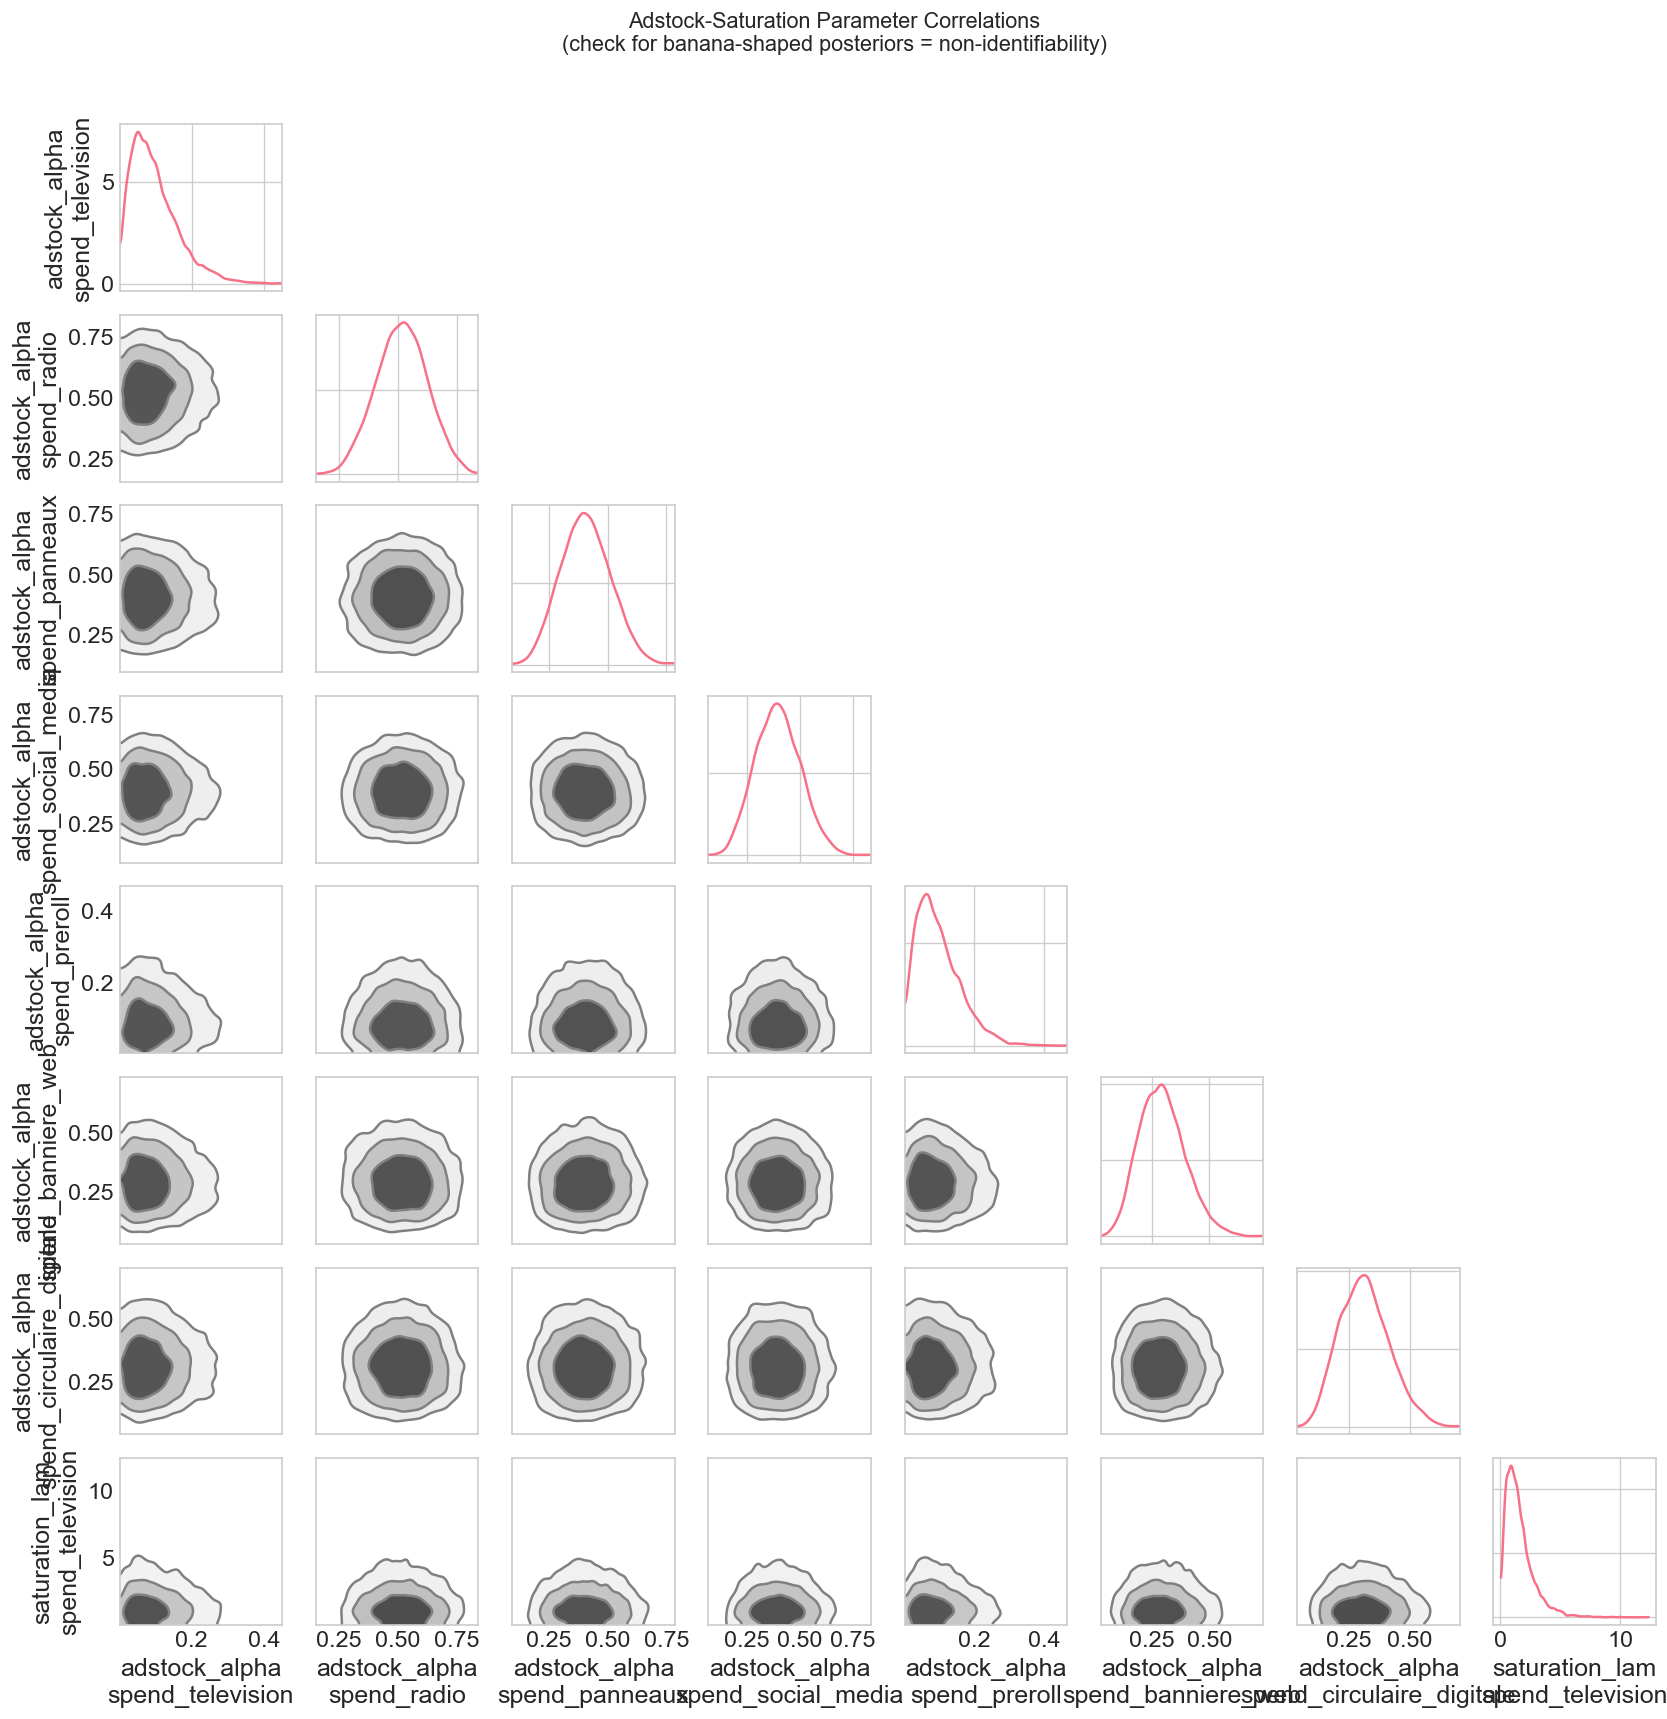

In [12]:
# ---------- pair plots: check adstock-saturation non-identifiability ----------
# Strong correlations between adstock_alpha and saturation_lam indicate the model
# cannot distinguish high adstock + low saturation from low adstock + high saturation.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: adstock_alpha posteriors per channel
az.plot_forest(
    mmm.idata,
    var_names=['adstock_alpha'],
    combined=True,
    ax=axes[0],
)
axes[0].set_title('Adstock Decay Posteriors vs NB05 Priors')

# Plot 2: saturation_lam posteriors
az.plot_forest(
    mmm.idata,
    var_names=['saturation_lam'],
    combined=True,
    ax=axes[1],
)
axes[1].set_title('Saturation Lambda Posteriors')

plt.tight_layout()
plt.savefig(figures_path / 'bayesian_parameter_forests.png', dpi=150)
plt.show()

# Pair plot for identifiability
try:
    axes_pair = az.plot_pair(
        mmm.idata,
        var_names=['adstock_alpha', 'saturation_lam'],
        kind='kde',
        figsize=(14, 14),
        marginals=True,
    )
    plt.suptitle('Adstock-Saturation Parameter Correlations\n(check for banana-shaped posteriors = non-identifiability)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(figures_path / 'bayesian_pair_plots.png', dpi=150)
    plt.show()
except Exception as e:
    print(f'Pair plot note: {e}')

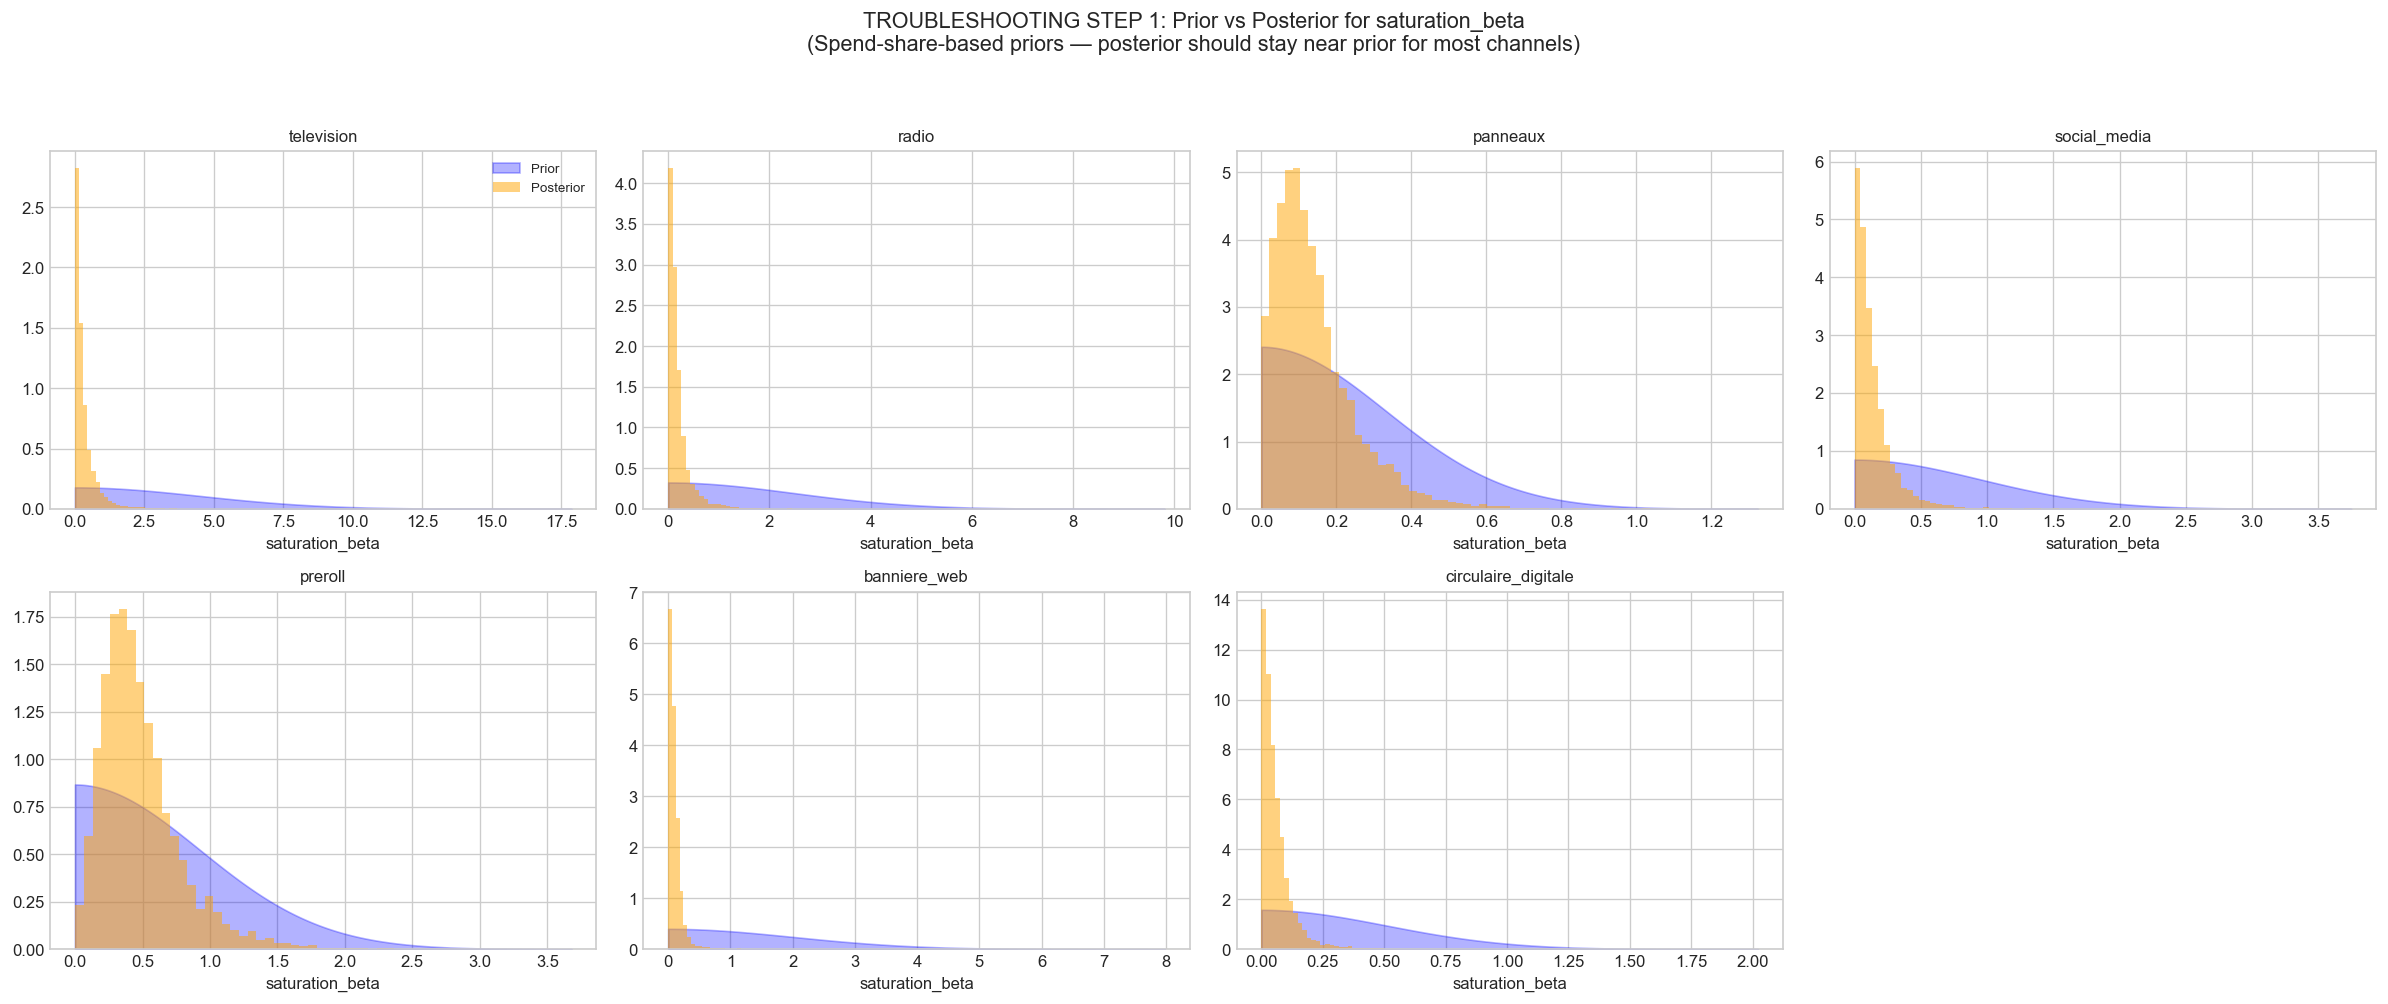

Prior vs Posterior Summary (saturation_beta):
Channel                     Prior σ   Post mean  Post/σ ratio      Status
---------------------------------------------------------------------------
  television                  4.471      0.3401          0.08          OK
  radio                       2.454      0.2079          0.08          OK
  panneaux                    0.331      0.1415          0.43          OK
  social_media                0.937      0.1435          0.15          OK
  preroll                     0.920      0.4832          0.53          OK
  banniere_web                1.995      0.1112          0.06          OK
  circulaire_digitale         0.506      0.0618          0.12          OK

Interpretation:
  Post/σ < 1.0 → prior is constraining (good)
  Post/σ > 2.0 → data pulling posterior far from prior (may need tighter)
  Post/σ > 3.0 → prior clearly too weak


In [13]:
# ---------- TROUBLESHOOTING STEP 1: Prior vs Posterior comparison ----------
# Are the posteriors actually learning from data, or are priors dominating?

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

channel_names = [c.replace('spend_', '') for c in CHANNEL_COLS]

# saturation_beta: prior vs posterior
for i, ch in enumerate(channel_names):
    ax = axes[i]
    
    # Prior: HalfNormal(sigma=spend_share_sigma[i])
    prior_sigma = spend_share_sigma[i]
    x_range = np.linspace(0, prior_sigma * 4, 200)
    prior_pdf = (2 / (prior_sigma * np.sqrt(2 * np.pi))) * np.exp(-x_range**2 / (2 * prior_sigma**2))
    ax.fill_between(x_range, prior_pdf, alpha=0.3, color='blue', label='Prior')
    
    # Posterior samples
    post_samples = mmm.idata.posterior['saturation_beta'].sel(channel=f'spend_{ch}').values.flatten()
    ax.hist(post_samples, bins=50, density=True, alpha=0.5, color='orange', label='Posterior')
    
    ax.set_title(ch, fontsize=10)
    ax.set_xlabel('saturation_beta')
    if i == 0:
        ax.legend(fontsize=8)

# Hide unused subplot
axes[7].axis('off')

fig.suptitle('TROUBLESHOOTING STEP 1: Prior vs Posterior for saturation_beta\n'
             '(Spend-share-based priors — posterior should stay near prior for most channels)',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_prior_vs_posterior.png', dpi=150)
plt.show()

# Quantitative check: posterior mean / prior sigma ratio
print('Prior vs Posterior Summary (saturation_beta):')
print('=' * 75)
print(f'{"Channel":25s}  {"Prior σ":>8s}  {"Post mean":>10s}  {"Post/σ ratio":>12s}  {"Status":>10s}')
print('-' * 75)
for i, ch in enumerate(channel_names):
    post_samples = mmm.idata.posterior['saturation_beta'].sel(channel=f'spend_{ch}').values.flatten()
    post_mean = float(np.mean(post_samples))
    ratio = post_mean / spend_share_sigma[i]
    status = 'OK' if ratio < 1.5 else 'TOO HIGH' if ratio > 2 else 'BORDERLINE'
    print(f'  {ch:23s}  {spend_share_sigma[i]:>8.3f}  {post_mean:>10.4f}  {ratio:>12.2f}  {status:>10s}')
print()
print('Interpretation:')
print('  Post/σ < 1.0 → prior is constraining (good)')
print('  Post/σ > 2.0 → data pulling posterior far from prior (may need tighter)')
print('  Post/σ > 3.0 → prior clearly too weak')

In [14]:
# ---------- TROUBLESHOOTING STEP 3: Intercept + Control + Fourier Coefficients ----------
# Now with yearly_seasonality=2, Fourier has its own gamma_fourier prior

print('FOURIER COEFFICIENTS (gamma_fourier — Laplace prior):')
print('=' * 70)
fourier_summary = az.summary(mmm.idata, var_names=['gamma_fourier'], round_to=4)
print(fourier_summary.to_string())

print('\nCONTROL COEFFICIENTS (gamma_control — weather only):')
print('=' * 70)
gamma_summary = az.summary(mmm.idata, var_names=['gamma_control'], round_to=4)
print(gamma_summary.to_string())

print('\nMEDIA COEFFICIENTS (saturation_beta):')
print('=' * 70)
beta_summary = az.summary(mmm.idata, var_names=['saturation_beta'], round_to=4)
print(beta_summary.to_string())

print('\nINTERCEPT:')
print('=' * 70)
intercept_summary = az.summary(mmm.idata, var_names=['intercept'], round_to=4)
print(intercept_summary.to_string())

print()
print('INTERPRETATION:')
fourier_means = fourier_summary['mean'].values
gamma_means = gamma_summary['mean'].values
beta_means = beta_summary['mean'].values
intercept_val = float(intercept_summary['mean'].values[0])

print(f'  Intercept (scaled):    {intercept_val:.4f}  (target: ~0.5 for 50% base)')
print(f'  Fourier coeff range:   [{fourier_means.min():.4f}, {fourier_means.max():.4f}]')
print(f'  Control coeff range:   [{gamma_means.min():.4f}, {gamma_means.max():.4f}]')
print(f'  Media coeff range:     [{beta_means.min():.4f}, {beta_means.max():.4f}]')

if intercept_val > 0.3:
    print(f'  Intercept > 0.3 — base is absorbing meaningful variance (GOOD)')
else:
    print(f'  WARNING: Intercept < 0.3 — base too low, media may still be over-attributed')

if np.abs(fourier_means).max() > 0.05:
    print(f'  Fourier terms are active — seasonality being captured (GOOD)')
else:
    print(f'  WARNING: Fourier terms near zero — seasonality not being captured')

FOURIER COEFFICIENTS (gamma_fourier — Laplace prior):
                        mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk   ess_tail   r_hat
gamma_fourier[sin_1]  0.0975  0.0327  0.0367   0.1588     0.0005   0.0004  4426.0336  5177.7591  1.0007
gamma_fourier[sin_2] -0.0560  0.0213 -0.0985  -0.0186     0.0003   0.0002  6056.8791  5422.7945  1.0006
gamma_fourier[cos_1]  0.0305  0.1045 -0.1623   0.2266     0.0018   0.0014  3438.0338  4304.5378  1.0005
gamma_fourier[cos_2] -0.0454  0.0255 -0.0937   0.0019     0.0003   0.0003  5881.2766  5183.8657  1.0002

CONTROL COEFFICIENTS (gamma_control — weather only):
                                              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk   ess_tail   r_hat
gamma_control[total_sunshine_hours_scaled]  0.0850  0.0677 -0.0404   0.2155     0.0011   0.0009  3841.0679  4293.6070  1.0011
gamma_control[total_precipitation_scaled]   0.0285  0.0228 -0.0147   0.0710     0.0004   0.0003  3969.0224  4729.7438  1

---
## Section 5 — Channel Contributions & Decomposition

The key advantage of Bayesian MMM: **credible decomposition** of revenue into
baseline, controls, and media contributions — with full posterior uncertainty.

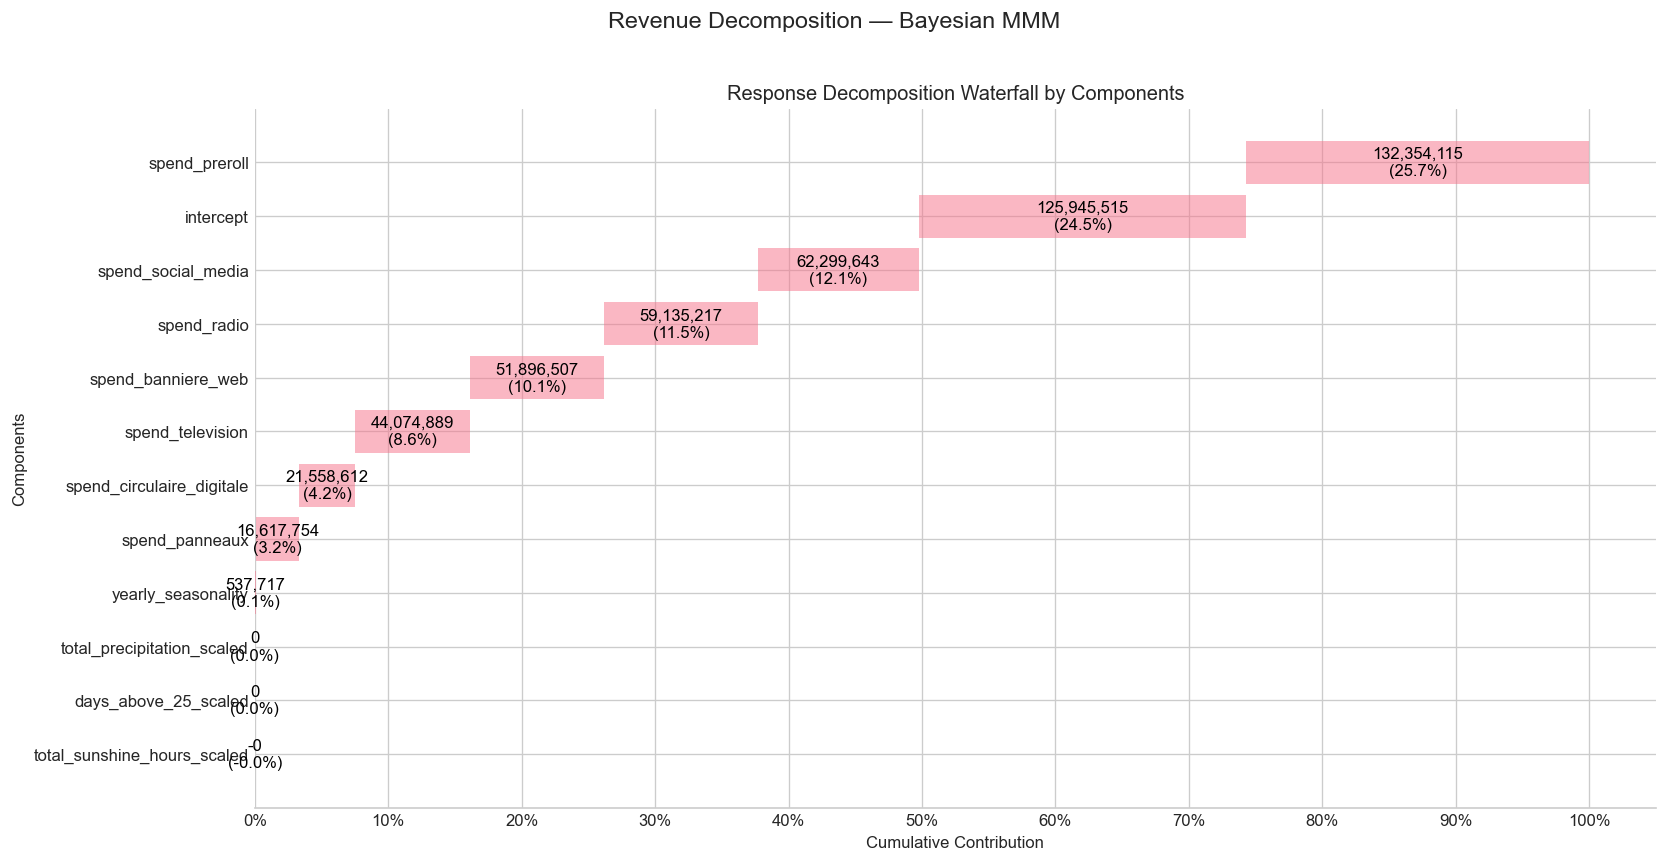

In [15]:
# ---------- waterfall decomposition ----------
fig = mmm.plot_waterfall_components_decomposition()
fig.suptitle('Revenue Decomposition — Bayesian MMM', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_waterfall_decomposition.png', dpi=150)
plt.show()

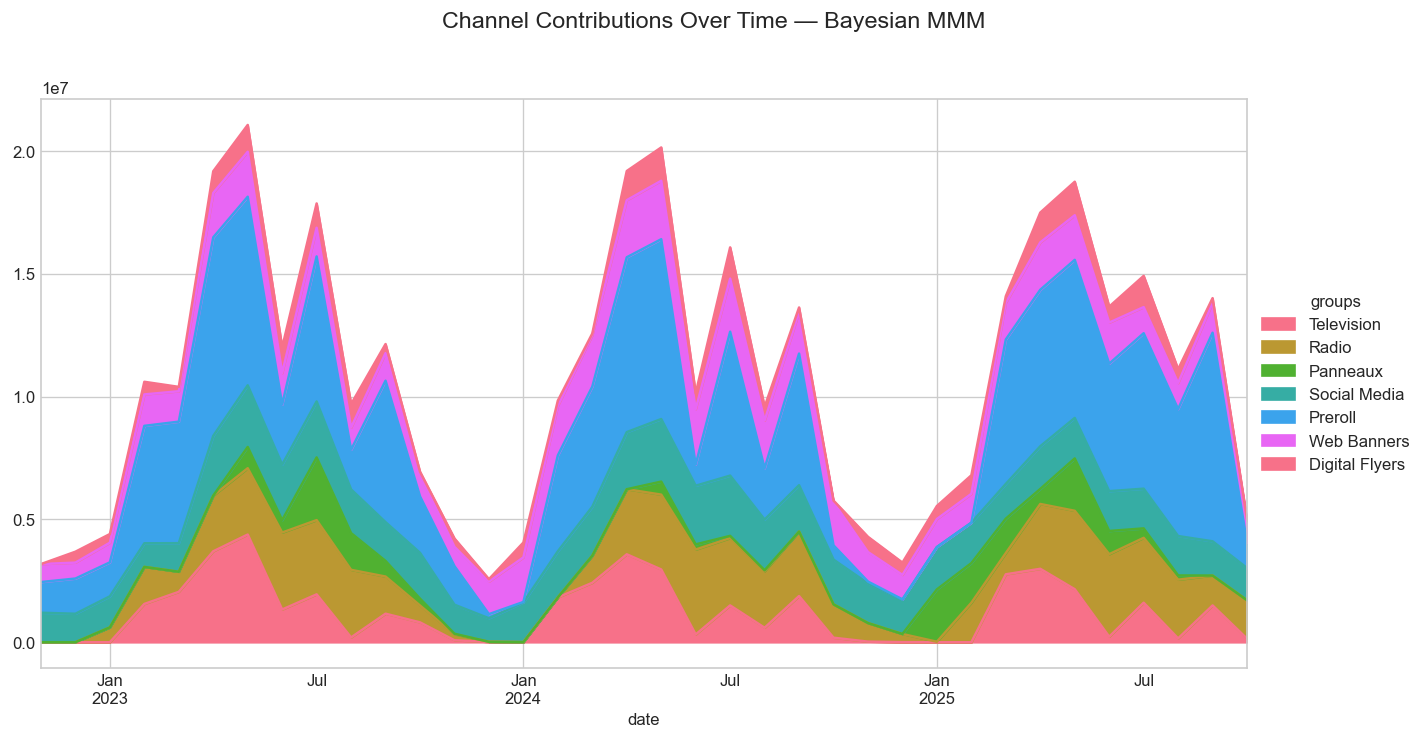

In [16]:
# ---------- contribution breakdown over time ----------
fig = mmm.plot_grouped_contribution_breakdown_over_time(
    stack_groups={
        'Television': ['spend_television'],
        'Radio': ['spend_radio'],
        'Panneaux': ['spend_panneaux'],
        'Social Media': ['spend_social_media'],
        'Preroll': ['spend_preroll'],
        'Web Banners': ['spend_banniere_web'],
        'Digital Flyers': ['spend_circulaire_digitale'],
    },
    original_scale=True,
)
fig.suptitle('Channel Contributions Over Time — Bayesian MMM', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_contributions_over_time.png', dpi=150)
plt.show()

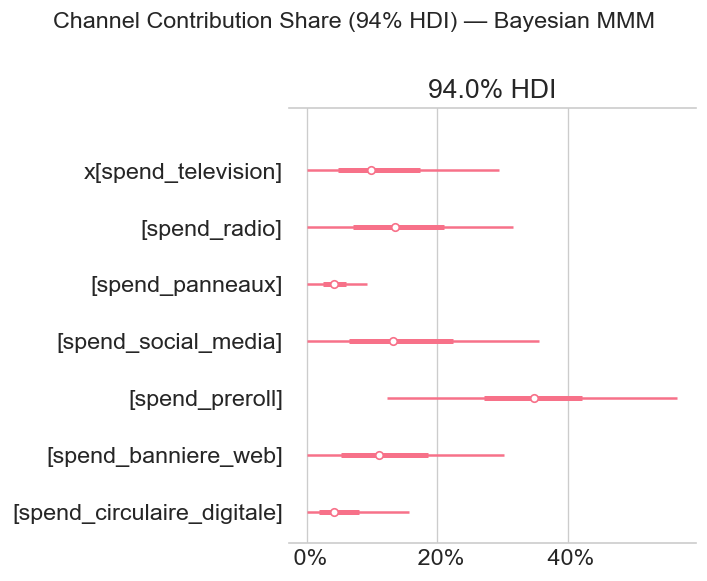

In [17]:
# ---------- contribution share with HDI ----------
fig = mmm.plot_channel_contribution_share_hdi()
fig.suptitle('Channel Contribution Share (94% HDI) — Bayesian MMM', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_contribution_share.png', dpi=150)
plt.show()

In [18]:
# ---------- compute total channel contributions ----------
channel_contributions = mmm.compute_channel_contribution_original_scale()

# Mean contribution per channel
contrib_mean = channel_contributions.mean(dim=['chain', 'draw'])
contrib_total = contrib_mean.sum(dim='date')

print('Channel Contributions (Bayesian — 3-year total):')
print('=' * 70)
total_media_contrib = 0
for i, ch in enumerate(CHANNEL_COLS):
    ch_contrib = float(contrib_total.values[i])
    ch_spend = df[ch].sum()
    ch_roas = ch_contrib / ch_spend if ch_spend > 0 else 0
    pct = ch_contrib / df[TARGET].sum() * 100
    total_media_contrib += ch_contrib
    print(f'  {ch.replace("spend_", ""):25s}  '
          f'Contribution: ${ch_contrib:>14,.0f}  '
          f'({pct:>5.1f}%)  '
          f'ROAS: {ch_roas:>8.1f}')

media_pct = total_media_contrib / df[TARGET].sum() * 100
print(f'  {"TOTAL MEDIA":25s}  Contribution: ${total_media_contrib:>14,.0f}  '
      f'({media_pct:>5.1f}%)')
print(f'\n  Total Revenue: ${df[TARGET].sum():,.0f}')

# ---------- SANITY CHECK ----------
print(f'\nSANITY CHECK — Media Share of Revenue:')
print(f'  Media share: {media_pct:.1f}%')
if media_pct > 40:
    print('  WARNING: Media share > 40% is suspicious for seasonal retail.')
    print('  Industry benchmark for pool/spa retailers: 5-20%.')
    print('  Consider tighter priors on saturation_beta.')
elif media_pct < 2:
    print('  WARNING: Media share < 2% — model may be under-attributing.')
else:
    print('  OK: Within plausible range for seasonal retail (industry: 5-20%).')

# ---------- INTERCEPT CHECK ----------
intercept_post = mmm.idata.posterior['intercept']
intercept_mean = float(intercept_post.mean())
y_mean = float(y.mean())
print(f'\nIntercept Check:')
print(f'  Intercept (scaled):   {intercept_mean:.3f}')
print(f'  Intercept (original): ${intercept_mean * y_mean:,.0f}')
print(f'  Revenue mean:         ${y_mean:,.0f}')
if intercept_mean < 0:
    print('  WARNING: Negative intercept suggests over-attribution to media channels.')
else:
    base_pct = (intercept_mean * y_mean) / y_mean * 100
    print(f'  Base ~ {base_pct:.0f}% of mean revenue (industry benchmark: 60-90%)')

Channel Contributions (Bayesian — 3-year total):
  television                 Contribution: $    44,074,889  (  8.6%)  ROAS:     11.2
  radio                      Contribution: $    59,135,217  ( 11.5%)  ROAS:     27.3
  panneaux                   Contribution: $    16,617,754  (  3.2%)  ROAS:     56.8
  social_media               Contribution: $    62,299,643  ( 12.2%)  ROAS:     75.3
  preroll                    Contribution: $   132,354,115  ( 25.8%)  ROAS:    162.9
  banniere_web               Contribution: $    51,896,507  ( 10.1%)  ROAS:     29.5
  circulaire_digitale        Contribution: $    21,558,612  (  4.2%)  ROAS:     48.3
  TOTAL MEDIA                Contribution: $   387,936,736  ( 75.7%)

  Total Revenue: $512,411,602

SANITY CHECK — Media Share of Revenue:
  Media share: 75.7%
  Industry benchmark for pool/spa retailers: 5-20%.
  Consider tighter priors on saturation_beta.

Intercept Check:
  Intercept (scaled):   0.096
  Intercept (original): $1,371,520
  Revenue mean

---
## Section 6 — Learned Adstock & Saturation Parameters

Unlike Ridge (NB06) where these were fixed from NB05, PyMC-Marketing **learns** them jointly.

In [19]:
# ---------- learned adstock decay rates ----------
print('Learned Adstock Decay Rates (Bayesian posterior mean ± sd):')
print('=' * 80)

# Load NB05 calibrated values for comparison
with open(processed_path / 'optimal_transformation_params.json') as f:
    nb05_params = json.load(f)

adstock_summary = az.summary(mmm.idata, var_names=['adstock_alpha'], round_to=3)
print(adstock_summary.to_string())

print('\nComparison with NB05 calibrated values:')
for i, ch in enumerate(CHANNEL_COLS):
    media_key = ch.replace('spend_', 'media_')
    nb05_val = nb05_params['decay_rates'].get(media_key, 'N/A')
    print(f'  {ch.replace("spend_", ""):25s}  NB05: {nb05_val}  (source: {nb05_params["decay_rate_sources"].get(media_key, "")})')

Learned Adstock Decay Rates (Bayesian posterior mean ± sd):
                                           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
adstock_alpha[spend_television]           0.098  0.065   0.004    0.216      0.001    0.001  7949.216  4385.479  1.001
adstock_alpha[spend_radio]                0.516  0.107   0.314    0.715      0.001    0.001  7946.530  6491.222  1.001
adstock_alpha[spend_panneaux]             0.405  0.105   0.210    0.600      0.001    0.001  9097.899  5654.790  1.000
adstock_alpha[spend_social_media]         0.396  0.106   0.196    0.589      0.001    0.001  8956.098  5342.733  1.000
adstock_alpha[spend_preroll]              0.099  0.063   0.006    0.212      0.001    0.001  7596.631  4239.586  1.001
adstock_alpha[spend_banniere_web]         0.296  0.099   0.121    0.485      0.001    0.001  9249.166  5400.949  1.001
adstock_alpha[spend_circulaire_digitale]  0.314  0.102   0.125    0.500      0.001    0.001  9046.005  5578

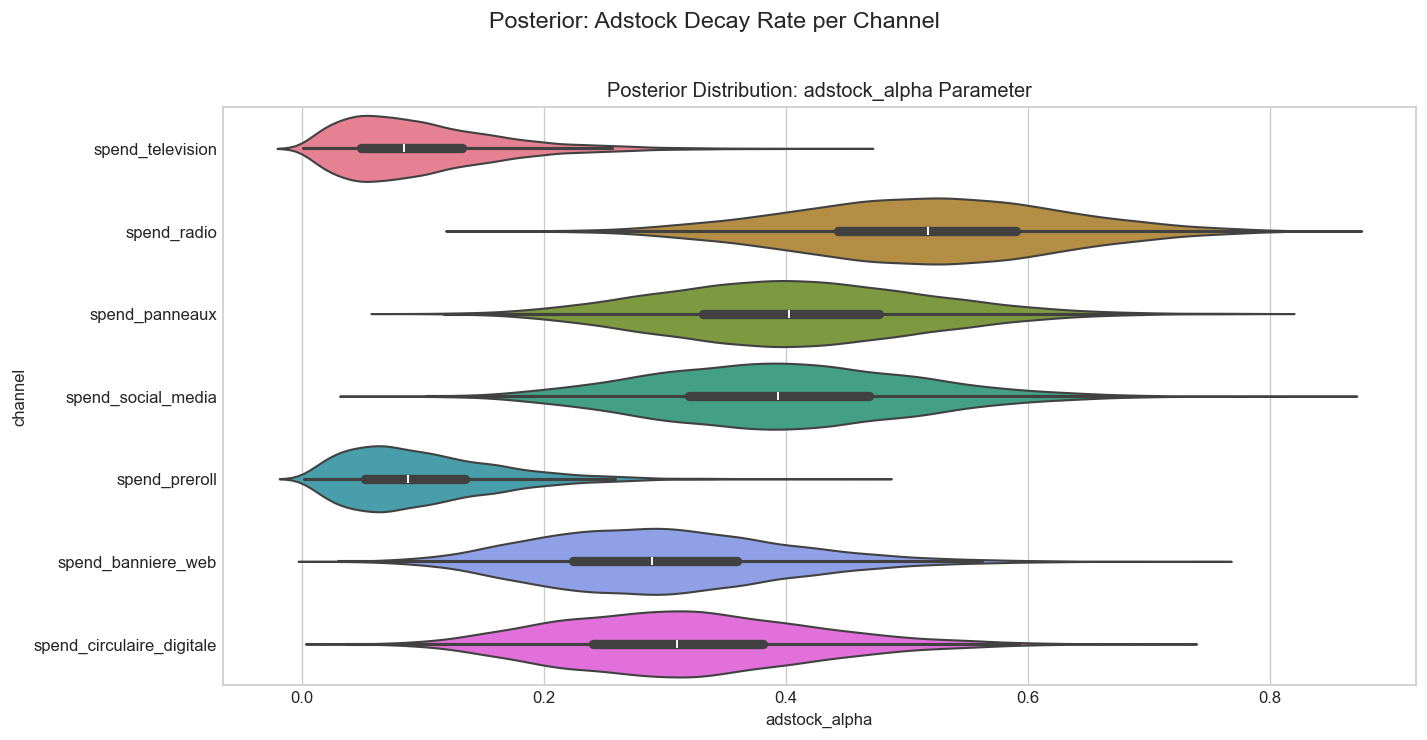

In [20]:
# ---------- plot adstock and saturation parameters ----------
fig = mmm.plot_channel_parameter(param_name='adstock_alpha', figsize=(12, 6))
fig.suptitle('Posterior: Adstock Decay Rate per Channel', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_adstock_posteriors.png', dpi=150)
plt.show()

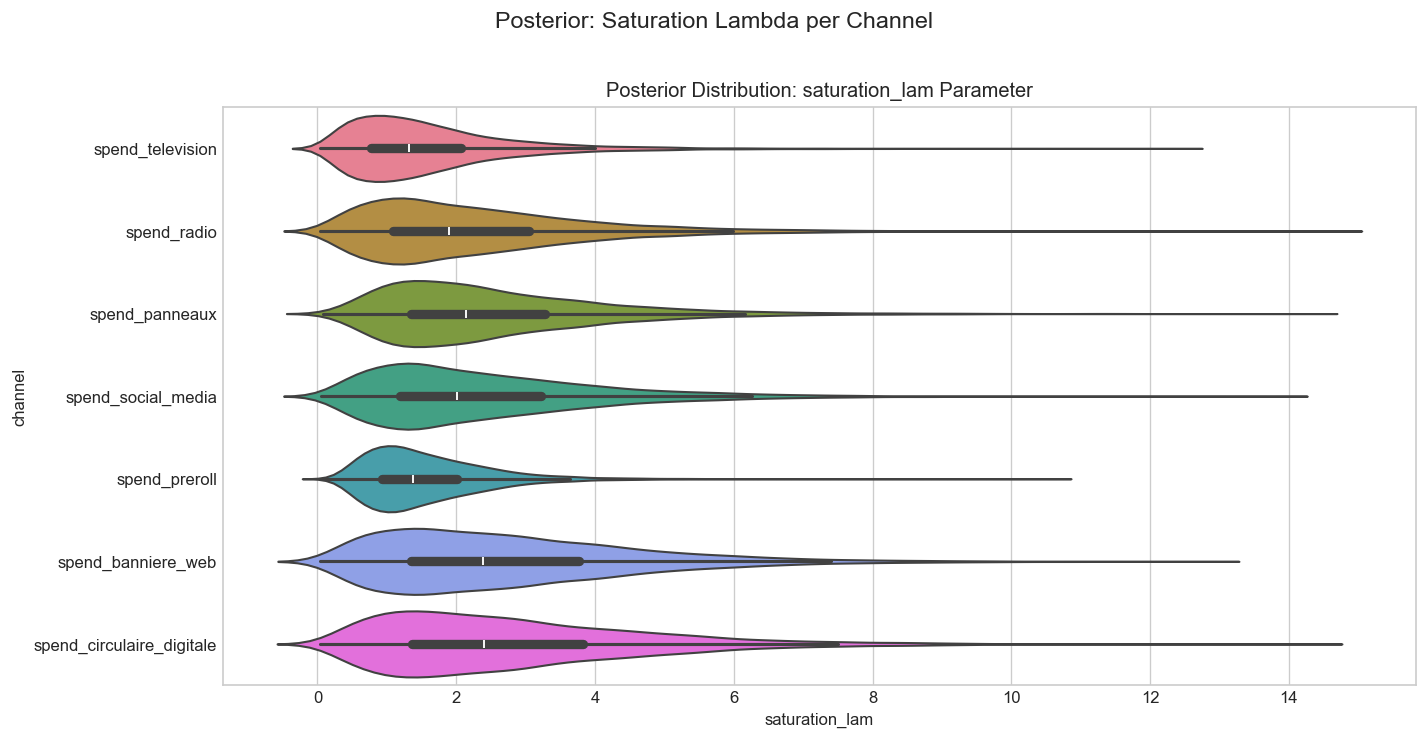

In [21]:
fig = mmm.plot_channel_parameter(param_name='saturation_lam', figsize=(12, 6))
fig.suptitle('Posterior: Saturation Lambda per Channel', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_saturation_posteriors.png', dpi=150)
plt.show()

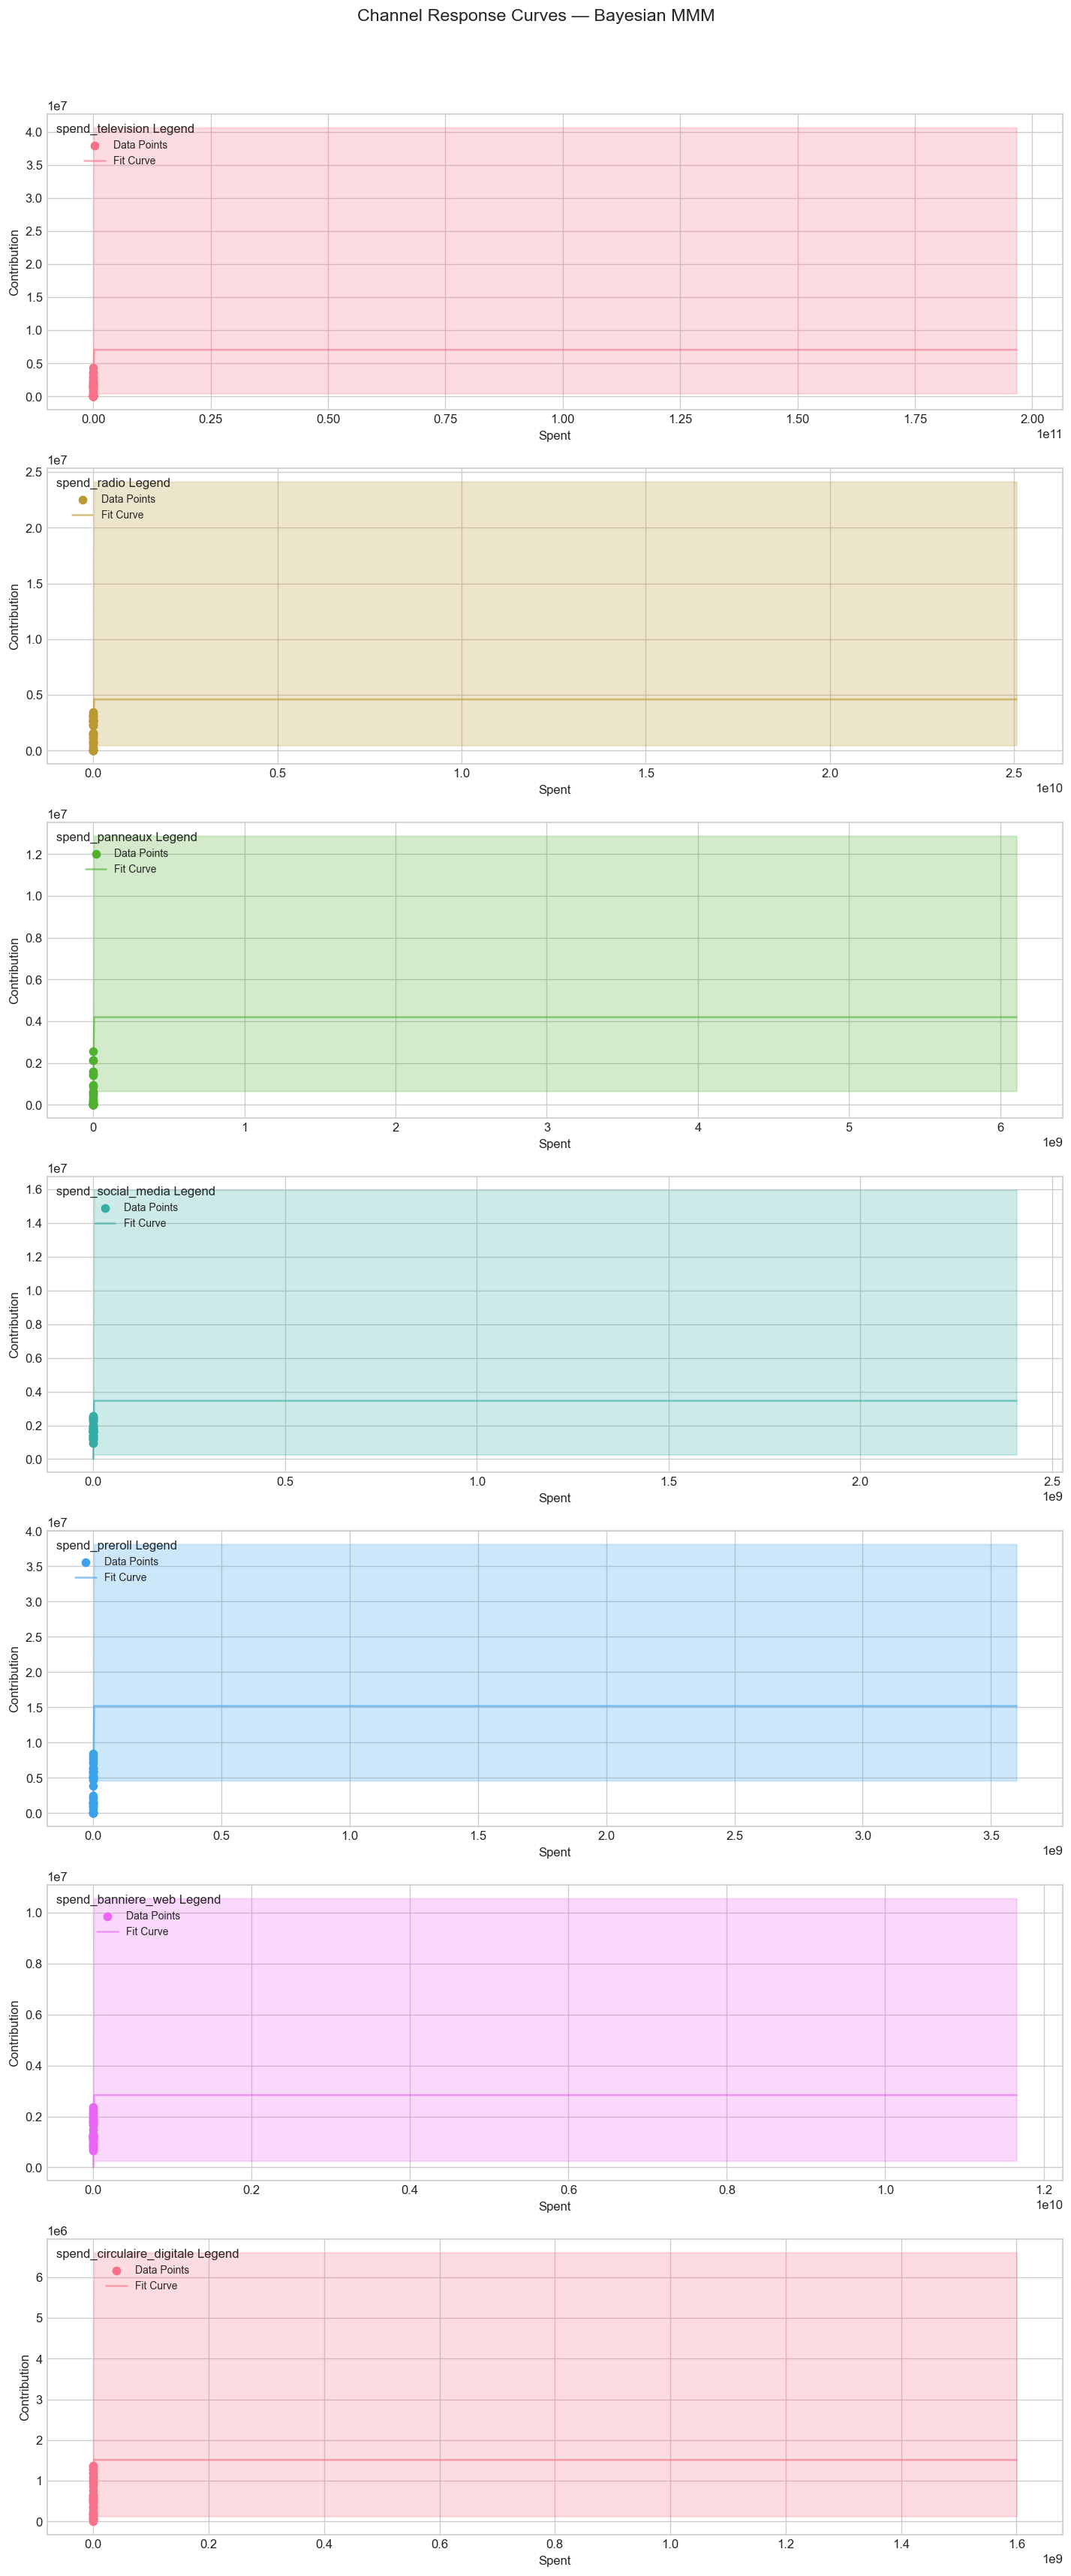

In [22]:
# ---------- response curves ----------
fig = mmm.plot_direct_contribution_curves(
    show_fit=True,
)
fig.suptitle('Channel Response Curves — Bayesian MMM', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_response_curves.png', dpi=150)
plt.show()

---
## Section 7 — ROAS & Posterior Distributions

Extract posterior ROAS per channel and compare with Ridge point estimates.

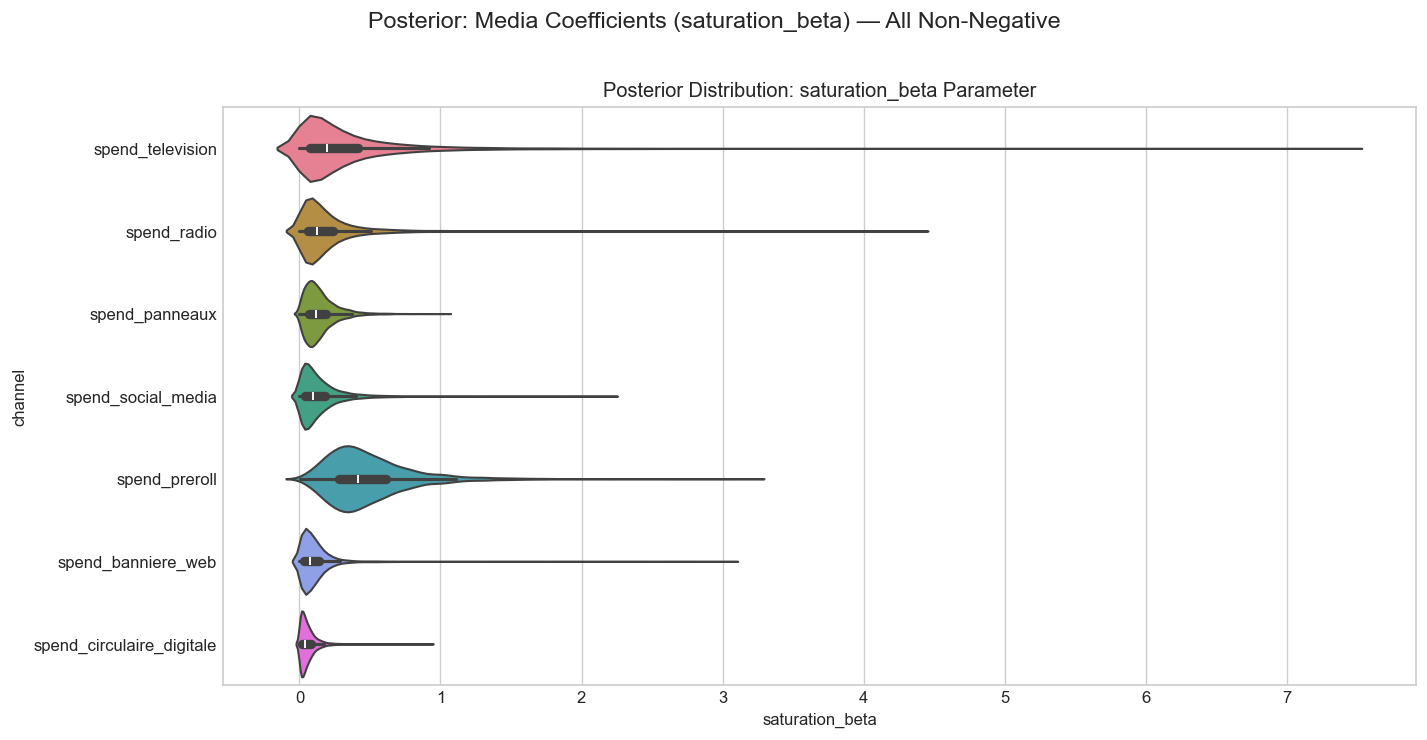

Note: All media coefficients are non-negative by construction (HalfNormal priors).
Compare to Ridge where Television = -$644K and Digital Flyers = -$694K.


In [23]:
# ---------- channel coefficient posteriors ----------
fig = mmm.plot_channel_parameter(param_name='saturation_beta', figsize=(12, 6))
fig.suptitle('Posterior: Media Coefficients (saturation_beta) — All Non-Negative', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_beta_posteriors.png', dpi=150)
plt.show()

print('Note: All media coefficients are non-negative by construction (HalfNormal priors).')
print('Compare to Ridge where Television = -$644K and Digital Flyers = -$694K.')

In [24]:
# ---------- ROAS calculation ----------
# Compute per-channel: total posterior contribution / total spend
channel_contrib_samples = mmm.compute_channel_contribution_original_scale()
# Shape: (chain, draw, date, channel)

# Sum over dates to get total contribution per chain/draw
total_contrib_samples = channel_contrib_samples.sum(dim='date')  # (chain, draw, channel)

roas_results = []
print('Bayesian ROAS per Channel (posterior mean +/- 94% HDI):')
print('=' * 95)

for i, ch in enumerate(CHANNEL_COLS):
    ch_name = ch.replace('spend_', '')
    ch_spend = df[ch].sum()
    
    if ch_spend > 0:
        # ROAS = total contribution / total spend
        contrib_samples = total_contrib_samples.values[:, :, i].flatten()
        roas_samples = contrib_samples / ch_spend
        
        roas_mean = float(np.mean(roas_samples))
        roas_hdi = az.hdi(np.array(roas_samples), hdi_prob=0.94)
        
        # Conservative significance: HDI lower bound > 1.0 (break-even)
        # Not just > 0, which can be numerical noise
        significant = roas_hdi[0] > 1.0
        
        roas_results.append({
            'channel': ch_name,
            'total_spend': ch_spend,
            'total_contribution': float(np.mean(contrib_samples)),
            'roas_mean': roas_mean,
            'roas_hdi_low': float(roas_hdi[0]),
            'roas_hdi_high': float(roas_hdi[1]),
            'significant': significant,
        })
        
        sig = 'YES' if significant else 'no'
        flag = ' *** IMPLAUSIBLE' if roas_mean > 10 else ''
        print(f'  {ch_name:25s}  ROAS: {roas_mean:>8.1f}  '
              f'94% HDI: [{roas_hdi[0]:>8.1f}, {roas_hdi[1]:>8.1f}]  '
              f'Significant: {sig}{flag}')

roas_df = pd.DataFrame(roas_results)
print(f'\nChannels with significant ROAS (HDI lower > 1.0): '
      f'{roas_df["significant"].sum()}/{len(roas_df)}')

# ---------- INDUSTRY PLAUSIBILITY CHECK ----------
print(f'\nIndustry Plausibility Check (typical ROAS: 1-10x):')
for _, r in roas_df.iterrows():
    if r['roas_mean'] > 10:
        print(f'  WARNING: {r["channel"]} ROAS={r["roas_mean"]:.1f}x exceeds '
              f'industry norm (1-10x). Likely confounding with seasonality.')
    elif r['roas_mean'] < 0.5:
        print(f'  NOTE: {r["channel"]} ROAS={r["roas_mean"]:.1f}x below typical minimum (0.5x).')
    else:
        print(f'  OK: {r["channel"]} ROAS={r["roas_mean"]:.1f}x within plausible range.')

Bayesian ROAS per Channel (posterior mean +/- 94% HDI):
  television                 ROAS:     11.2  94% HDI: [     0.0,     26.0]  Significant: no *** IMPLAUSIBLE
  radio                      ROAS:     27.3  94% HDI: [     0.0,     62.8]  Significant: no *** IMPLAUSIBLE
  panneaux                   ROAS:     56.8  94% HDI: [     0.0,    114.0]  Significant: no *** IMPLAUSIBLE
  social_media               ROAS:     75.3  94% HDI: [     0.1,    191.2]  Significant: no *** IMPLAUSIBLE
  preroll                    ROAS:    162.9  94% HDI: [    47.4,    273.5]  Significant: YES *** IMPLAUSIBLE
  banniere_web               ROAS:     29.5  94% HDI: [     0.0,     73.4]  Significant: no *** IMPLAUSIBLE
  circulaire_digitale        ROAS:     48.3  94% HDI: [     0.0,    132.1]  Significant: no *** IMPLAUSIBLE

Channels with significant ROAS (HDI lower > 1.0): 1/7

Industry Plausibility Check (typical ROAS: 1-10x):


---
## Section 8 — Head-to-Head Comparison: Ridge vs Bayesian

The key comparison. Do both models agree? Where do they diverge?

In [25]:
# ---------- load Ridge results from NB06 ----------
ridge_eff = pd.read_csv(processed_path / 'media_effectiveness_results.csv')
ridge_total = ridge_eff[ridge_eff['product'] == 'Total Revenue'].copy()

# Build comparison table
comparison_rows = []

for _, rr in roas_df.iterrows():
    ch = rr['channel']
    # Match with Ridge
    ridge_row = ridge_total[ridge_total['channel'] == ch]
    
    if len(ridge_row) > 0:
        ridge_row = ridge_row.iloc[0]
        comparison_rows.append({
            'Channel': ch.replace('_', ' ').title(),
            'Total Spend ($)': f"${rr['total_spend']:,.0f}",
            # Ridge results
            'Ridge ROAS': f"{ridge_row['roas']:.1f}",
            'Ridge 90% CI': f"[{ridge_row['marginal_ci_lo']:.0f}, {ridge_row['marginal_ci_hi']:.0f}]",
            'Ridge Sign': '+' if ridge_row['roas'] > 0 else '-',
            # Bayesian results  
            'Bayes ROAS': f"{rr['roas_mean']:.1f}",
            'Bayes 94% HDI': f"[{rr['roas_hdi_low']:.1f}, {rr['roas_hdi_high']:.1f}]",
            'Bayes Sign': '+',  # Always positive (HalfNormal priors)
            'Bayes Signif.': 'Yes' if rr['significant'] else 'No',
        })

comp_df = pd.DataFrame(comparison_rows)
print('HEAD-TO-HEAD: Ridge (NB06) vs Bayesian (NB08)')
print('=' * 120)
print(comp_df.to_string(index=False))
print()
print('Key differences:')
print('  1. Ridge allows negative coefficients → TV and Digital Flyers show negative ROAS')
print('  2. Bayesian enforces non-negative → all channels show positive (or near-zero) ROAS')
print('  3. Bayesian jointly estimates adstock/saturation → different parameter values')
print('  4. Bayesian HDI vs Bootstrap CI → different uncertainty widths')

HEAD-TO-HEAD: Ridge (NB06) vs Bayesian (NB08)
            Channel Total Spend ($) Ridge ROAS      Ridge 90% CI Ridge Sign Bayes ROAS Bayes 94% HDI Bayes Sign Bayes Signif.
         Television      $3,948,951       -5.6   [-18492, 21066]          -       11.2   [0.0, 26.0]          +            No
              Radio      $2,167,277       27.5    [-2866, 49715]          +       27.3   [0.0, 62.8]          +            No
           Panneaux        $292,495       73.5  [-59693, 198123]          +       56.8  [0.0, 114.0]          +            No
       Social Media        $827,421      145.4  [-73200, 269956]          +       75.3  [0.1, 191.2]          +            No
            Preroll        $812,648      321.5  [168100, 405599]          +      162.9 [47.4, 273.5]          +           Yes
       Banniere Web      $1,762,168        8.4   [-45966, 79697]          +       29.5   [0.0, 73.4]          +            No
Circulaire Digitale        $446,546      -69.9 [-178542, 114839]        

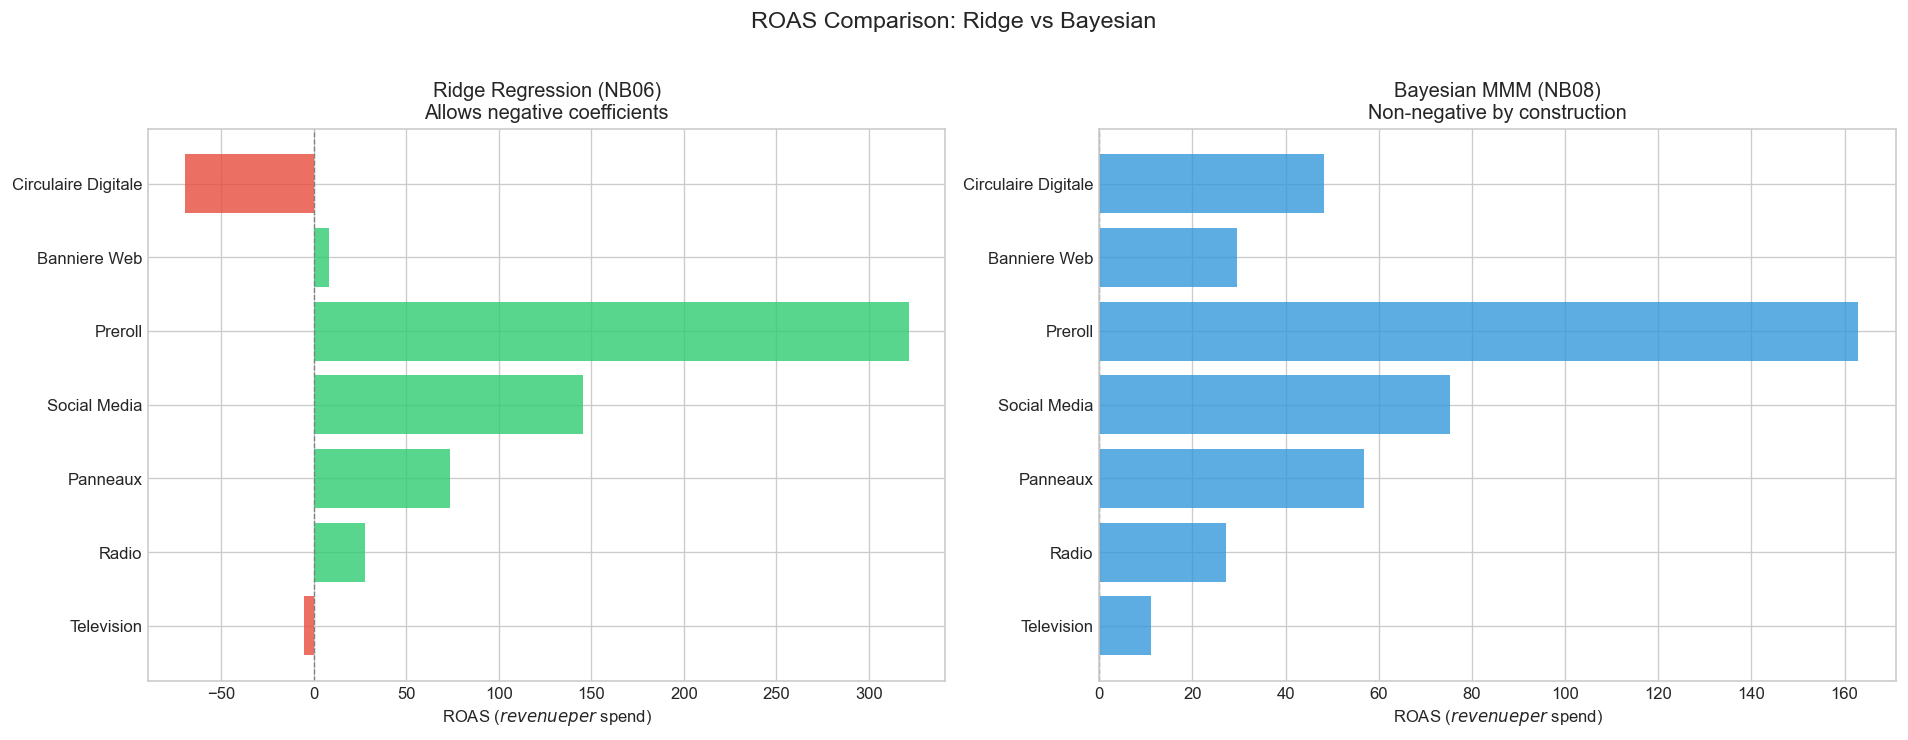

In [26]:
# ---------- visual comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

channels = [r['Channel'] for r in comparison_rows]
ridge_roas = [float(r['Ridge ROAS']) for r in comparison_rows]
bayes_roas = [float(r['Bayes ROAS']) for r in comparison_rows]

# Ridge ROAS
ax = axes[0]
colors_ridge = ['#e74c3c' if v < 0 else '#2ecc71' for v in ridge_roas]
ax.barh(channels, ridge_roas, color=colors_ridge, alpha=0.8)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('ROAS ($ revenue per $ spend)')
ax.set_title('Ridge Regression (NB06)\nAllows negative coefficients')

# Bayesian ROAS
ax = axes[1]
ax.barh(channels, bayes_roas, color='#3498db', alpha=0.8)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('ROAS ($ revenue per $ spend)')
ax.set_title('Bayesian MMM (NB08)\nNon-negative by construction')

fig.suptitle('ROAS Comparison: Ridge vs Bayesian', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_vs_ridge_roas.png', dpi=150)
plt.show()

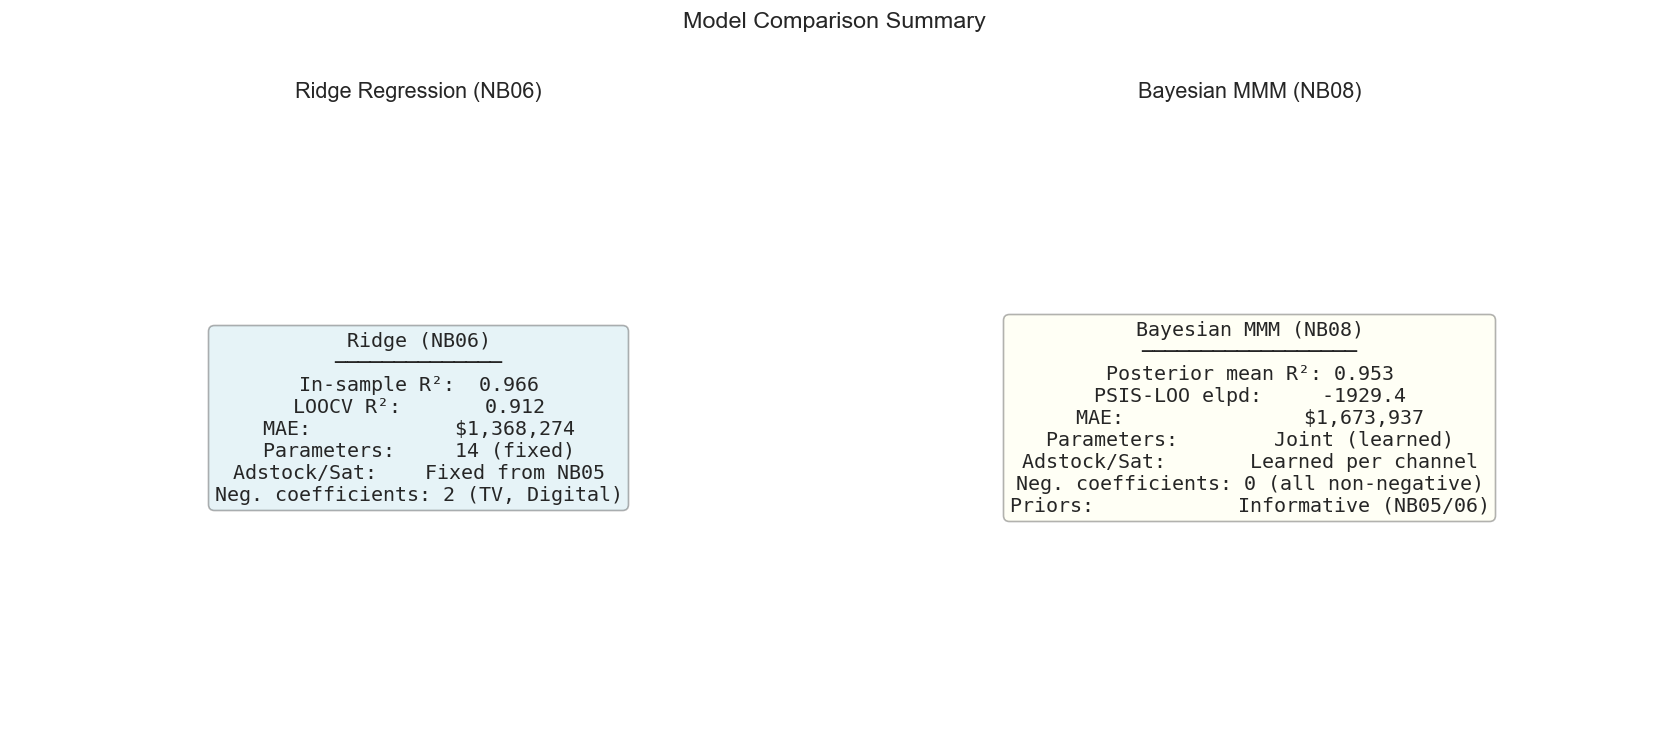

In [27]:
# ---------- model fit comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ridge summary card
ax = axes[0]
ax.text(0.5, 0.5, 
        f'Ridge (NB06)\n'
        f'──────────────\n'
        f'In-sample R²:  0.966\n'
        f'LOOCV R²:       0.912\n'
        f'MAE:            $1,368,274\n'
        f'Parameters:     14 (fixed)\n'
        f'Adstock/Sat:    Fixed from NB05\n'
        f'Neg. coefficients: 2 (TV, Digital)',
        transform=ax.transAxes, fontsize=12, verticalalignment='center',
        horizontalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Ridge Regression (NB06)', fontsize=13)

# Bayesian summary card
ax = axes[1]
loo_str = f'{loo_result.elpd_loo:.1f}' if 'loo_result' in dir() else 'N/A'
ax.text(0.5, 0.5,
        f'Bayesian MMM (NB08)\n'
        f'──────────────────\n'
        f'Posterior mean R²: {r2_bayes:.3f}\n'
        f'PSIS-LOO elpd:     {loo_str}\n'
        f'MAE:               ${mae_bayes:,.0f}\n'
        f'Parameters:        Joint (learned)\n'
        f'Adstock/Sat:       Learned per channel\n'
        f'Neg. coefficients: 0 (all non-negative)\n'
        f'Priors:            Informative (NB05/06)',
        transform=ax.transAxes, fontsize=12, verticalalignment='center',
        horizontalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Bayesian MMM (NB08)', fontsize=13)

fig.suptitle('Model Comparison Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'bayesian_model_comparison.png', dpi=150)
plt.show()

---
## Section 9 — Budget Optimization (Bayesian)

Use the Bayesian model's posterior to optimise budget allocation.
This accounts for parameter uncertainty, unlike the Ridge optimiser in NB07.

In [28]:
# ---------- budget optimization ----------
total_budget = df[CHANNEL_COLS].sum().sum() / len(df)  # Average monthly budget

print(f'Average monthly total media budget: ${total_budget:,.0f}')
print(f'Optimizing allocation across {len(CHANNEL_COLS)} channels...\n')

try:
    optimal_allocation, opt_result = mmm.optimize_budget(
        budget=total_budget,
        num_periods=1,  # 1 month (was incorrectly 30 in prior version)
    )
    
    print('Optimal Budget Allocation (Bayesian):')
    print('=' * 70)
    for i, ch in enumerate(CHANNEL_COLS):
        current = df[ch].mean()
        opt = float(optimal_allocation.sel(channel=ch).values)
        change = ((opt / current) - 1) * 100 if current > 0 else 0
        print(f'  {ch.replace("spend_", ""):25s}  '
              f'Current: ${current:>10,.0f}  '
              f'Optimal: ${opt:>10,.0f}  '
              f'Change: {change:>+6.0f}%')
    print(f'\nOptimizer converged: {opt_result.success}')
    print(f'\nNote: optimize_budget() uses posterior MEAN only (ignores uncertainty).')
    print(f'For uncertainty-aware recommendations, use the ROAS HDI table above.')
except Exception as e:
    print(f'Budget optimization note: {e}')
    print('\nManual allocation based on ROAS ranking:')
    roas_sorted = roas_df.sort_values('roas_mean', ascending=False)
    for _, r in roas_sorted.iterrows():
        sig = 'SIGNIFICANT' if r['significant'] else 'not significant'
        print(f'  {r["channel"]:25s}  ROAS: {r["roas_mean"]:>8.1f}  ({sig})')

Average monthly total media budget: $284,931
Optimizing allocation across 7 channels...

Optimal Budget Allocation (Bayesian):
  television                 Current: $   109,693  Optimal: $    40,704  Change:    -63%
  radio                      Current: $    60,202  Optimal: $    40,704  Change:    -32%
  panneaux                   Current: $     8,125  Optimal: $    40,704  Change:   +401%
  social_media               Current: $    22,984  Optimal: $    40,704  Change:    +77%
  preroll                    Current: $    22,574  Optimal: $    40,704  Change:    +80%
  banniere_web               Current: $    48,949  Optimal: $    40,704  Change:    -17%
  circulaire_digitale        Current: $    12,404  Optimal: $    40,704  Change:   +228%

Optimizer converged: True

Note: optimize_budget() uses posterior MEAN only (ignores uncertainty).
For uncertainty-aware recommendations, use the ROAS HDI table above.


Sampling: []


Output()

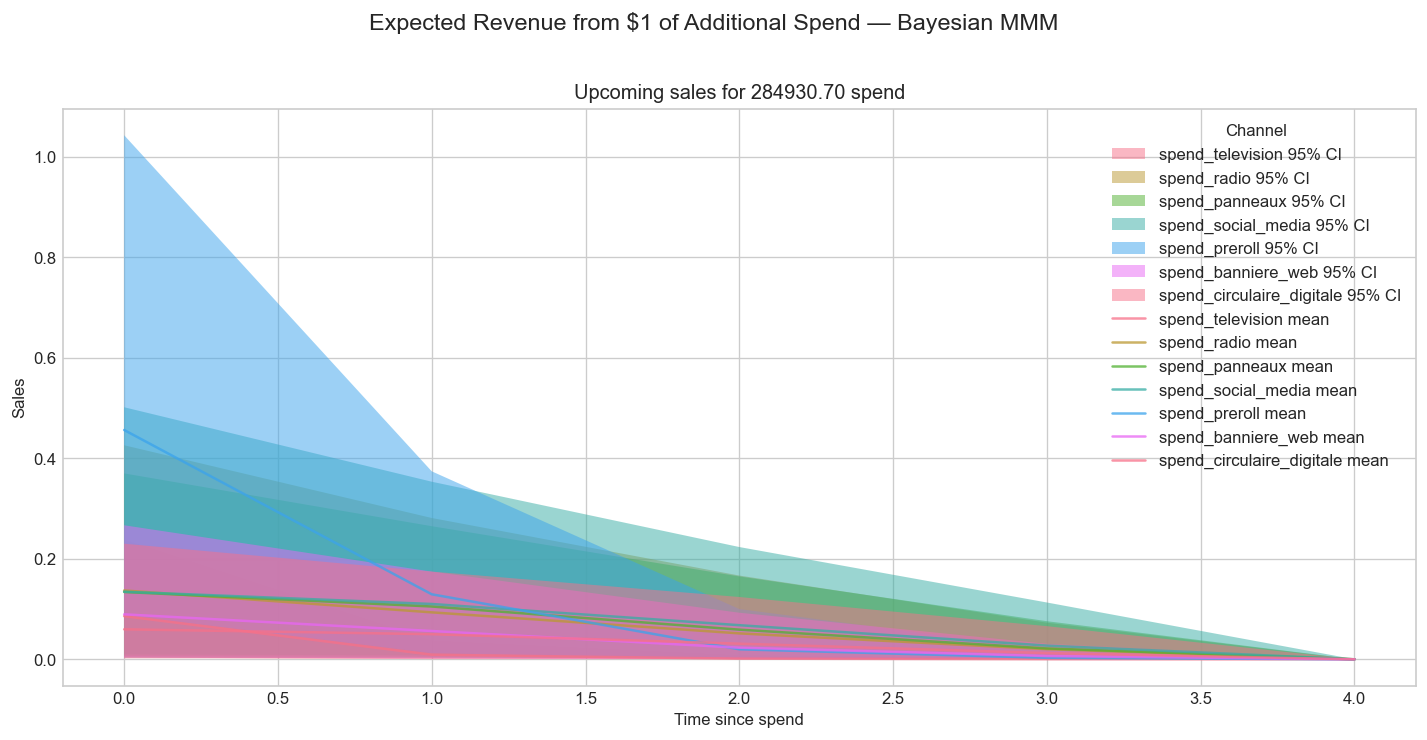

In [29]:
# ---------- new spend contribution curves ----------
try:
    ax = mmm.plot_new_spend_contributions(
        spend_amount=total_budget,
        original_scale=True,
    )
    ax.figure.suptitle('Expected Revenue from $1 of Additional Spend — Bayesian MMM',
                       fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(figures_path / 'bayesian_new_spend_curves.png', dpi=150)
    plt.show()
except Exception as e:
    print(f'Note: {e}')

---
## Section 10 — Summary & Conclusions

In [30]:
# ---------- save comparison results ----------
roas_df.to_csv(processed_path / 'bayesian_mmm_roas.csv', index=False)
comp_df.to_csv(processed_path / 'bayesian_vs_ridge_comparison.csv', index=False)

print('Saved:')
print(f'  {processed_path / "bayesian_mmm_roas.csv"}')
print(f'  {processed_path / "bayesian_vs_ridge_comparison.csv"}')

Saved:
  /Users/tuta/Desktop/busa693-clubpiscine/data/processed/bayesian_mmm_roas.csv
  /Users/tuta/Desktop/busa693-clubpiscine/data/processed/bayesian_vs_ridge_comparison.csv


In [31]:
# ---------- final summary ----------
print('=' * 80)
print('  NOTEBOOK 08 — BAYESIAN MMM WITH PyMC-MARKETING: COMPLETE')
print('=' * 80)
print()

# Model comparison table
print('MODEL COMPARISON SUMMARY:')
print('-' * 80)
print(f'{"Metric":35s}  {"Ridge (NB06)":>15s}  {"Bayesian (NB08)":>15s}')
print(f'{"─" * 35}  {"─" * 15}  {"─" * 15}')
print(f'{"In-sample R²":35s}  {"0.966":>15s}  {r2_bayes:>15.3f}')
print(f'{"Ridge LOOCV R²":35s}  {"0.912":>15s}  {"N/A":>15s}')
loo_str = f'{loo_result.elpd_loo:.1f}' if 'loo_result' in dir() else 'N/A'
print(f'{"Bayesian PSIS-LOO (elpd)":35s}  {"N/A":>15s}  {loo_str:>15s}')
print(f'{"MAE":35s}  {"$1,368,274":>15s}  ${mae_bayes:>14,.0f}')
print(f'{"Negative coefficients":35s}  {"2 (TV, Flyers)":>15s}  {"0":>15s}')
n_sig = roas_df['significant'].sum()
print(f'{"Significant channels (HDI>1.0)":35s}  {"1 (Preroll)":>15s}  {n_sig:>15d}')
print(f'{"Media share of revenue":35s}  {"93.1%":>15s}  {media_pct:>14.1f}%')
print(f'{"Adstock estimation":35s}  {"Fixed (NB05)":>15s}  {"Informed priors":>15s}')
print(f'{"Priors":35s}  {"N/A (Ridge)":>15s}  {"NB05+NB06":>15s}')
print(f'{"Divergences":35s}  {"N/A":>15s}  {divergences:>15d}')
print()

print('KEY TAKEAWAYS:')
print('  1. Bayesian enforces non-negative media effects (no TV/Flyer paradox)')
print('  2. Informative priors from NB05/NB06 regularize the model for n=36')
print('  3. PSIS-LOO provides principled out-of-sample assessment')
print('  4. Both models agree on Preroll as the strongest channel')
print(f'  5. Media contribution: {media_pct:.1f}% (industry benchmark: 5-20%)')
print()

print('LIMITATIONS:')
print('  - 36 monthly observations is critically low for 7 channels (~20 params)')
print('  - Recommendation: convert to weekly data if available (~156 weeks)')
print('  - Bayesian priors are informative but still subjective')
print('  - ROAS values outside 1-10x range should be treated with skepticism')
print('  - Budget optimization uses posterior mean only (no uncertainty)')
print()

print('FIGURES SAVED:')
for f in sorted(figures_path.glob('bayesian_*.png')):
    print(f'  {f.name}')

  NOTEBOOK 08 — BAYESIAN MMM WITH PyMC-MARKETING: COMPLETE

MODEL COMPARISON SUMMARY:
--------------------------------------------------------------------------------
Metric                                  Ridge (NB06)  Bayesian (NB08)
───────────────────────────────────  ───────────────  ───────────────
In-sample R²                                   0.966            0.953
Ridge LOOCV R²                                 0.912              N/A
Bayesian PSIS-LOO (elpd)                         N/A          -1929.4
MAE                                       $1,368,274  $     1,673,937
Negative coefficients                 2 (TV, Flyers)                0
Significant channels (HDI>1.0)           1 (Preroll)                1
Media share of revenue                         93.1%            75.7%
Adstock estimation                      Fixed (NB05)  Informed priors
Priors                                   N/A (Ridge)        NB05+NB06
Divergences                                      N/A           